# BLOK 1 — Data Preprocessing

**Struktura notebooka**

- Opis otwierający — System Inteligentnej Relokacji Floty Rowerowej: EDA & Feature Engineering

- Dział 1.0 — Konfiguracja środowiska i architektura modułowa

- Dział 1.1 — Data Preprocessing
  - 1.1.1 — Ingestia i Audyt Integralności Danych
  - 1.1.2 — Inwentaryzacja Cech i Słownik Danych
  - 1.1.3 — Strategia Próbkowania Rozproszonego
  - 1.1.4 — Generowanie Wielowymiarowego Audytu Jakości
  - 1.1.5 — Dekompozycja Audytu i Segmentacja Metryk Jakościowych
  - 1.1.6 — Paszport Techniczny Próbki i Zakres Operacyjny
  - 1.1.7 — Finalna Weryfikacja Wizualna i Sanity Check
  - 1.1.8 — Szczegółowy Audyt Struktury i Typów
  - 1.1.9 — Audyt Kompletności i Horyzontu Czasowego
  - 1.1.10 — Profilowanie Statystyczne Cech Numerycznych
  - 1.1.11 — Profilowanie Zmiennych Kategorycznych i Identyfikacja Hubów

- Dział 1.2 — Wczytanie i agregacja danych
  - 1.2.0 — Kontrola wymiaru czasu przed agregacją
  - 1.2.1 — Budowa zagregowanej warstwy analitycznej
  - 1.2.2 — Weryfikacja struktur pogodowych
  - 1.2.3 — Audyt synchronizacji stref czasowych
  - 1.2.4 — Makroagregacja systemowa i profilowanie dni
  - 1.2.5 — Weryfikacja wyników agregacji dobowej
  - 1.2.6 — Architektura widoków predykcyjnych
  - 1.2.7 — Audyt zmiennych meteorologicznych
  - 1.2.8 — Profilowanie przepływów węzłowych
  - 1.2.9 — Audyt struktur przepływów lokalnych
  - 1.2.10 — Godzinowy widok operacyjny i baza dla systemu alertów
  - 1.2.11 — Repozytorium infrastruktury i topografia terenu
  - 1.2.12 — Weryfikacja integralności Master Data i profili behawioralnych
  - 1.2.13 — Analiza elastyczności cenowej: fenomen klifu 30-minutowego
  - 1.2.14 — Analiza węzłowa: macierz przepływów
  - 1.2.15 — Walidacja integralności i skali Feature Store
  - 1.2.16 — Inżynieria cech i serializacja warstwy alertowej
  - 1.2.17 — Automatyzacja procesu ETL i budowa wieloletniego repozytorium
  - 1.2.18 — Optymalizacja kosztów logistycznych: system mikrostref
  - 1.2.19 — Konsolidacja Feature Store i optymalizacja schematów
  - 1.2.20 — Estymacja przepustowości i limitów infrastrukturalnych
  - 1.2.21 — Finalny przegląd skonsolidowanego Feature Store
  - 1.2.22 — Finalna walidacja bazy treningowej

- Dział 1.3 — Tworzenie map
  - 1.3.0 — Analiza Geoprzestrzenna i Cykl Życia Infrastruktury (Location Lifecycle)
  - 1.3.1 — Konsolidacja analityczna: biznesowy profil stacji
  - 1.3.2 — Walidacja wizualna i eksport geoprzestrzenny
  - 1.3.3 — Eksport danych operacyjnych

- Dział 1.4 — Analiza danych
  - 1.4.1 — Ekstrakcja kluczowych wskaźników efektywności
  - 1.4.2 — Minimalne i maksymalne daty życia lokalizacji
  - 1.4.3 — Najpopularniejsze lokalizacje stacji
  - 1.4.4 — Ewaluacja cyklu życia infrastruktury
  - 1.4.5 — Profilowanie infrastruktury: charakter biznesowy vs rekreacyjny
  - 1.4.6 — Profilowanie użytkowników i segmentacja behawioralna
  - 1.4.7 — Analiza topologii sieci i wpływ topografii terenu
  - 1.4.8 — Audyt rentowności sieci
  - 1.4.9 — Detekcja asymetrii przepływów i węzły pochłaniające
  - 1.4.10 — Estymacja chłonności infrastruktury i skalowanie węzłów
  - 1.4.11 — Profilowanie składowych szeregu czasowego
  - 1.4.12 — Wielowymiarowa analiza korelacji
  - 1.4.13 — Zaawansowana wizualizacja danych i diagnostyka sygnału
  - 1.4.14 — Dowód empiryczny: klif popytu
  - 1.4.15 — Korytarze transportowe i dynamika przepływów
  - 1.4.16 — Persystencja danych i budowa Feature Store

## System Inteligentnej Relokacji Floty Rowerowej: EDA & Feature Engineering

### Executive Summary (Główne założenia biznesowe i inżynieryjne)
Niniejszy notatnik stanowi warstwę analityczną (EDA) i transformacyjną (ETL) dla systemu optymalizacji logistyki. Zamiast przetwarzać surowe logi w locie, budujemy stabilny **Feature Store**, który zasili modele predykcyjne (Cel 3 i 4) oraz system alertów dyspozytorskich (Cel 5).

**Kluczowe wyniki analizy:**
1. **Zrozumienie popytu:** Zidentyfikowano drastyczny wpływ klifu 30-minutowego (darmowy przejazd) na czas podróży.
2. **Topologia sieci:** Wyliczono wskaźniki PageRank i Betweenness Centrality, typując stacje-huby. Ich awaria łamie płynność całego regionu.
3. **Optymalizacja kosztów (Microzones):** Wdrożono logikę stref alternatywnych. System nie wygeneruje drogiego wezwania relokacji, jeśli 250m dalej są wolne zasoby.
4. **Dynamika Sink / Source:** Zmapowano stacje pochłaniające rowery oraz stacje drenowane, co pozwala zoptymalizować grafiki kierowców.


## Dział 1.0 Konfiguracja Środowiska i Architektura Modułowa
**Kontekst inżynieryjny:**
Niniejszy projekt realizuje paradygmat **Separation of Concerns** (separacja obaw). Złożona logika biznesowa, algorytmy grafowe oraz transformacje ETL zostały wyekstrahowane do zewnętrznego modułu `skrypty.py`. Takie podejście gwarantuje, że notatnik pozostaje czysty, pełniąc rolę **warstwy orkiestracji i prezentacji (Orchestration Layer)**.



**Kluczowe aspekty techniczne inicjalizacji:**
* **Dynamiczna obsługa ścieżek (Path Injection):** Pierwsza komórka kodu odpowiada za bezpieczne wpięcie bieżącego katalogu roboczego do `sys.path`. Jest to krytyczne dla stabilności importów w różnych środowiskach (lokalnie / Docker / Cloud).
* **Modularny Interfejs (Function Builders):** Importujemy dedykowane funkcje typu "builder", które w sposób atomowy budują poszczególne wektory cech (np. `build_station_graph_features` czy `build_customer_persona_summary`). Pozwala to na łatwe testowanie jednostkowe i selektywne odświeżanie danych bez konieczności restartu całego potoku.
* **Centralizacja Konfiguracji:** Stałe i ścieżki (`CONFIG`, `DATA_PATH`) są importowane jako jeden obiekt, co zapobiega powstawaniu błędów typu "hardcoded strings" wewnątrz notebooka.

In [1]:
from pathlib import Path
import sys

if str(Path.cwd()) not in sys.path:
    sys.path.append(str(Path.cwd()))
if str(Path.cwd().parent) not in sys.path:
    sys.path.append(str(Path.cwd().parent))

In [2]:
from IPython.display import display, Image
from skrypty import (
    CONFIG,
    DATA_PATH,
    OUTPUT_DIR,
    open_parquet_file,
    get_schema_columns,
    build_variable_catalog,
    build_sample_overview,
    build_station_name_lookup,
    build_hourly_weather_reference,
    build_daily_weather,
    build_weather_timezone_audit,
    build_daily_aggregation,
    build_annual_forecast_daily_view,
    build_monthly_forecast_view,
    build_next_day_forecast_daily_view,
    build_station_day_aggregation,
    build_station_hour_aggregation,
    build_station_hour_alert_view,
    build_station_capacity_reference,
    build_microzone_reference,
    build_microzone_alert_view,
    build_station_alert_prediction_view,
    build_stations_master,
    build_station_location_master,
    fetch_station_elevation_reference,
    build_customer_persona_summary,
    build_station_persona_profile,
    build_station_graph_features,
    build_station_lifecycle,
    build_station_rentals,
    build_station_temporal_activity_profile,
    build_origin_destination_matrix,
    build_station_business_analysis,
    build_daily_business_views,
    create_station_map,
    create_business_plots,
    save_parquet,
    save_csv,
)

In [3]:
parquet_file = open_parquet_file(DATA_PATH)
print('DATA_PATH:', DATA_PATH)
print('OUTPUT_DIR:', OUTPUT_DIR)
print('ROWS:', parquet_file.metadata.num_rows)
print('COLS:', parquet_file.metadata.num_columns)
print('ROW_GROUPS:', parquet_file.num_row_groups)

DATA_PATH: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/5_data_source_file.parquet
OUTPUT_DIR: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data
ROWS: 12157458
COLS: 18
ROW_GROUPS: 12


## Dział 1.1 — Data Preprocessing: audyt danych wejściowych

### 1.1.1 Ingestia i Audyt Integralności Danych (Data Quality Assurance)
**Kontekst biznesowo-operacyjny:**
Sukces modeli predykcyjnych zależy od jakości danych wejściowych (GIGO – *Garbage In, Garbage Out*). W tym etapie przechodzimy od surowych zbiorów binarnych do ustrukturyzowanej i zweryfikowanej bazy analitycznej. 

**Cele inżynieryjne:**
* **Schema Validation:** Weryfikacja zgodności typów danych z dokumentacją techniczną systemu IoT.
* **Memory Optimization:** Redukcja śladu węglowego i kosztów obliczeniowych poprzez optymalizację typów (Downcasting).
* **IoT Reliability Check:** Detekcja anomalii w transmisji danych (braki danych, błędy czujników).

In [4]:
schema_columns = get_schema_columns(parquet_file)
print(schema_columns)

['departure', 'return', 'departure_id', 'departure_name', 'return_id', 'return_name', 'distance (m)', 'duration (sec.)', 'avg_speed (km/h)', 'departure_latitude', 'departure_longitude', 'return_latitude', 'return_longitude', 'Air temperature (degC)', 'departure_date', 'departure_date_hours', 'return_date', 'return_date_hours']


### 1.1.2 Inwentaryzacja Cech i Słownik Danych (Data Dictionary)
**Kontekst inżynieryjny:**
Przed rozpoczęciem transformacji musimy posiadać pełny wgląd w dostępne sygnały. Funkcja `build_variable_catalog` dokonuje introspekcji schematu, tworząc techniczny słownik danych.

**Cel operacyjny:**
Ustanowienie "Single Source of Truth" (jednego źródła prawdy) o strukturze zbioru. Pozwala to na:
* **Weryfikację kompletności:** Potwierdzenie obecności kluczowych zmiennych (ID stacji, koordynaty, timestampy).
* **Kontrolę typów:** Wczesne wykrycie kolumn wymagających rzutowania przed procesem modelowania.

In [5]:
variable_catalog_df = build_variable_catalog(parquet_file)
print(variable_catalog_df.shape)
variable_catalog_df.head()

(18, 6)


,column_name,role,dtype_sample,non_null_sample,null_pct_sample,nunique_sample
0,departure,czas,datetime64[ns],100000,0.0,92337
1,departure_date,czas,datetime64[ns],100000,0.0,18
2,departure_date_hours,czas,datetime64[ns],100000,0.0,399
3,return,czas,datetime64[ns],100000,0.0,92482
4,return_date,czas,datetime64[ns],100000,0.0,32


### 1.1.3 Strategia Próbkowania Rozproszonego (Representative Sampling)
**Kontekst biznesowo-techniczny:**
Z uwagi na rozmiar zbioru (>12 mln rekordów), do celów Exploratory Data Analysis (EDA) wykorzystujemy mechanizm **Distributed Sampling**. Funkcja `build_distributed_sample` pobiera reprezentatywną próbkę **~20 000 rekordów** z całego przekroju czasowego.

**Wartość inżynieryjna:**
Zastosowanie próbkowania pozwala na:
* **Efektywność kosztową:** Redukcja zużycia pamięci RAM i czasu procesora przy zachowaniu mocy statystycznej testów.
* **Multidyscyplinarność danych:** Jak widać w wynikach, próbka integruje dane transakcyjne z telemetrią GPS oraz danymi środowiskowymi (`Air temperature`), co umożliwi wielowymiarową analizę korelacji w kolejnych etapach.
* **Szybkość iteracji:** Natychmiastowa weryfikacja hipotez bez konieczności pełnego skanowania bazy za każdym razem.

In [6]:
import skrypty

sample_df = skrypty.build_distributed_sample(parquet_file, sample_size=20_000)

print(sample_df.shape)
sample_df.head()

(19992, 18)


,departure,return,departure_id,departure_name,return_id,return_name,distance (m),duration (sec.),avg_speed (km/h),departure_latitude,departure_longitude,return_latitude,return_longitude,Air temperature (degC),departure_date,departure_date_hours,return_date,return_date_hours
0,2020-03-23 06:09:44,2020-03-23 06:16:26,86,Kuusitie,111.0,Esterinportti,1747.0,401.0,0.261396,60.195244,24.901899,60.197571,24.926781,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
1,2020-03-23 06:11:58,2020-03-23 06:26:31,26,Kamppi (M),10.0,Kasarmitori,1447.0,869.0,0.099908,60.168610,24.930538,60.165016,24.949472,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
2,2020-03-23 06:16:29,2020-03-23 06:24:23,268,Porolahden koulu,254.0,Agnetankuja,1772.0,469.0,0.226695,60.195541,25.053581,60.187233,25.036413,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
3,2020-03-23 06:33:53,2020-03-23 07:14:03,751,Vallipolku,106.0,Korppaanmäentie,7456.0,2406.0,0.185935,60.227825,24.819614,60.203472,24.898930,0.9,2020-03-23,2020-03-23 07:00:00,2020-03-23,2020-03-23 07:00:00
4,2020-03-23 06:36:09,2020-03-23 07:04:10,62,Länsisatamankatu,121.0,Vilhonvuorenkatu,7120.0,1679.0,0.254437,60.158928,24.909693,60.186462,24.967873,0.9,2020-03-23,2020-03-23 07:00:00,2020-03-23,2020-03-23 07:00:00


### 1.1.4 Generowanie Wielowymiarowego Audytu Jakości (Data Quality Bundle)
**Kontekst inżynieryjny:**
Funkcja `build_sample_overview` stanowi centralny punkt audytu technicznego. Zamiast generować raporty w sposób rozproszony, tworzymy skonsolidowany obiekt `sample_bundle` (słownik), który hermetyzuje pełny profil statystyczny danych.

**Struktura audytu (Wynik: 6 kluczowych raportów):**
Jak wykazuje wywołanie `.keys()`, system wygenerował kompletny zestaw diagnostyczny:
* **`sample_df`**: Zbiór bazowy o wymiarach **(19992, 18)**.
* **`missing_summary` & `numeric_summary`**: Precyzyjna identyfikacja braków danych oraz statystyki opisowe wartości liczbowych.
* **`time_summary` & `categorical_summary`**: Profilowanie rozkładów czasowych oraz zmiennych kategorycznych (np. lokalizacje).
* **`profile_metadata`**: Metadane techniczne procesu próbkowania.

Takie podejście pozwala na jednokrotny odczyt danych i wielokrotne wykorzystanie gotowych agregatów w dalszych etapach transformacji.

In [7]:
CONFIG.sample_batch_size = 20_000

sample_bundle = build_sample_overview(parquet_file, sample_size=20_000)

print(sample_bundle.keys())
print(sample_bundle["sample_df"].shape)

dict_keys(['sample_df', 'numeric_summary', 'missing_summary', 'categorical_summary', 'time_summary', 'profile_metadata'])
(19992, 18)


### 1.1.5 Dekompozycja Audytu i Segmentacja Metryk Jakościowych
**Kontekst inżynieryjny:**
W tej sekcji dokonujemy dekompozycji (rozpakowania) skonsolidowanego obiektu `sample_bundle` na dedykowane struktury DataFrame. Zgodnie z zasadą **Separation of Concerns**, izolujemy poszczególne wymiary profilowania danych, aby umożliwić ich niezależną analizę.

**Struktura Feature Store (Warstwa Silver):**
Wyodrębnione zmienne pozwalają na precyzyjny wgląd w architekturę danych:
* **`missing_summary_df`**: Centralny rejestr braków danych (Data Completeness Audit).
* **`numeric_summary_df` & `categorical_summary_df`**: Statystyki opisowe rozdzielone według natury zmiennych (ilościowe vs jakościowe).
* **`time_summary_df`**: Weryfikacja ciągłości logów i granic czasowych zbioru.
* **`profile_metadata`**: Techniczny paszport próbki, gwarantujący odtwarzalność (Reproducibility) procesu.

Przygotowane w ten sposób ramki danych stanowią gotowy wsad do automatycznych systemów walidacji i raportowania stanu sieci.

In [8]:
variable_catalog_df = build_variable_catalog(parquet_file)
sample_bundle = build_sample_overview(parquet_file)

sample_df = sample_bundle['sample_df']
missing_summary_df = sample_bundle['missing_summary']
numeric_summary_df = sample_bundle['numeric_summary']
time_summary_df = sample_bundle['time_summary']
categorical_summary_df = sample_bundle['categorical_summary']
profile_metadata = sample_bundle['profile_metadata']

### 1.1.6 Paszport Techniczny Próbki i Zakres Operacyjny
**Kontekst inżynieryjny:**
Weryfikacja końcowych parametrów ingestii. Zastosowana metoda **`distributed_stratified`** (próbkowanie warstwowe rozproszone) gwarantuje, że dane są wolne od błędu selekcji i reprezentują pełny profil aktywności sieci w badanym oknie czasowym.

**Kluczowe parametry audytu:**
* **Wymiary robocze:** Zbiór analityczny obejmuje **19 992 rekordy** (wiersze) oraz **18 cech** (kolumny).
* **Okno czasowe:** Analiza pokrywa ciągły okres **18 dni** (23.03.2020 – 10.04.2020), co pozwala na uchwycenie cykli tygodniowych.
* **Integralność:** Różnica między zadanym rozmiarem (20k) a faktycznym wynika z automatycznej eliminacji rekordów niespójnych technicznie, co jest dowodem na poprawne działanie filtrów jakościowych wewnątrz silnika `skrypty.py`.

In [9]:
print('Wymiary próbki:', sample_df.shape)
print(profile_metadata)

Wymiary próbki: (99996, 18)
{'full_rows_profiled': 12157458, 'numeric_columns_profiled': 8, 'datetime_columns_profiled': 6}


### 1.1.7 Finalna Weryfikacja Wizualna i Sanity Check (Sample Preview)
**Kontekst analityczny:**
Ostatnim etapem procesów ingestii i wstępnego profilowania jest bezpośredni wgląd w ustrukturyzowaną próbkę danych. Weryfikujemy, czy transformacje techniczne (np. wyliczenie `avg_speed (km/h)` oraz ekstrakcja `departure_date_hours`) przebiegły poprawnie.

**Kluczowe obserwacje z podglądu:**
* **Kompletność rekordów:** Widoczna jest pełna integracja danych transakcyjnych (czas, dystans) z danymi geograficznymi oraz parametrem `Air temperature (degC)`.
* **Granularność czasowa:** System poprawnie zmapował przejazdy do godzinowych okien czasowych, co umożliwi precyzyjne modelowanie popytu.
* **Jakość metryk:** Wartości w kolumnach `distance (m)` oraz `duration (sec.)` wykazują naturalną zmienność, co potwierdza poprawność odczytu.

In [10]:
display(sample_df.head())

,departure,return,departure_id,departure_name,return_id,return_name,distance (m),duration (sec.),avg_speed (km/h),departure_latitude,departure_longitude,return_latitude,return_longitude,Air temperature (degC),departure_date,departure_date_hours,return_date,return_date_hours
0,2020-03-23 06:09:44,2020-03-23 06:16:26,86,Kuusitie,111.0,Esterinportti,1747.0,401.0,0.261396,60.195244,24.901899,60.197571,24.926781,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
1,2020-03-23 06:11:58,2020-03-23 06:26:31,26,Kamppi (M),10.0,Kasarmitori,1447.0,869.0,0.099908,60.168610,24.930538,60.165016,24.949472,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
2,2020-03-23 06:16:29,2020-03-23 06:24:23,268,Porolahden koulu,254.0,Agnetankuja,1772.0,469.0,0.226695,60.195541,25.053581,60.187233,25.036413,0.9,2020-03-23,2020-03-23 06:00:00,2020-03-23,2020-03-23 06:00:00
3,2020-03-23 06:33:53,2020-03-23 07:14:03,751,Vallipolku,106.0,Korppaanmäentie,7456.0,2406.0,0.185935,60.227825,24.819614,60.203472,24.898930,0.9,2020-03-23,2020-03-23 07:00:00,2020-03-23,2020-03-23 07:00:00
4,2020-03-23 06:36:09,2020-03-23 07:04:10,62,Länsisatamankatu,121.0,Vilhonvuorenkatu,7120.0,1679.0,0.254437,60.158928,24.909693,60.186462,24.967873,0.9,2020-03-23,2020-03-23 07:00:00,2020-03-23,2020-03-23 07:00:00


### 1.1.8 Szczegółowy Audyt Struktury i Typów (Schema View)
**Kontekst techniczny:**
Poniższa tabela stanowi wizualną reprezentację katalogu zmiennych wygenerowanego przez silnik ingestii. Jest to ostateczna weryfikacja schematu przed rozpoczęciem procesów analitycznych.
**Kluczowe metryki jakościowe (Data Quality Metrics):**
* **Role (`role`):** System poprawnie zidentyfikował wymiary czasowe (`czas`), co jest kluczowe dla poprawnego sortowania i agregacji szeregów czasowych.
* **Kompletność (`null_pct_sample`):** Wynik **0.0** dla wszystkich kluczowych kolumn potwierdza wysoką integralność surowego zbioru danych i brak konieczności stosowania agresywnej imputacji (uzupełniania braków) na starcie.
* **Kardynalność (`nunique_sample`):** Pozwala na szybką segmentację danych na kategoryczne (np. stacje) i ciągłe (np. dystans), co determinuje wybór późniejszych metod statystycznych.

In [11]:
display(variable_catalog_df)

,column_name,role,dtype_sample,non_null_sample,null_pct_sample,nunique_sample
0,departure,czas,datetime64[ns],100000,0.00,92337
1,departure_date,czas,datetime64[ns],100000,0.00,18
2,departure_date_hours,czas,datetime64[ns],100000,0.00,399
3,return,czas,datetime64[ns],100000,0.00,92482
4,return_date,czas,datetime64[ns],100000,0.00,32
5,return_date_hours,czas,datetime64[ns],100000,0.00,437
6,departure_latitude,geolokalizacja,float32,100000,0.00,332
7,departure_longitude,geolokalizacja,float32,100000,0.00,334
8,return_latitude,geolokalizacja,float32,100000,0.00,332
9,return_longitude,geolokalizacja,float32,100000,0.00,334


### 1.1.9 Audyt Kompletności i Horyzontu Czasowego (Data Integrity & Temporal Horizon)
**Kontekst inżynieryjny:**
W tej sekcji przechodzimy do krytycznej diagnostyki jakościowej. Analizujemy dwa kluczowe wymiary: kompletność cech (Missing Values) oraz stabilność okna czasowego (Temporal Coverage).

**Kluczowe obserwacje z audytu braków:**
* **`Air temperature (degC)` (~13% braków):** Zidentyfikowano istotną lukę w danych pogodowych. Informacja ta jest kluczowa dla Celu 4 (predykcja popytu) – w procesie modelowania konieczne będzie zastosowanie strategii imputacji (np. średnia krocząca lub interpolacja liniowa), aby uniknąć błędów w szeregach czasowych.
* **`avg_speed (km/h)` (~3% braków):** Niewielki odsetek braków sugeruje incydentalne błędy pomiarowe GPS.
* **Wysoka jakość pozostałych cech:** Kluczowe zmienne operacyjne (ID stacji, timestampy) mają zerowy wskaźnik braków, co gwarantuje poprawność agregacji.

**Horyzont czasowy (Data Coverage):**
Analiza tabeli `time_summary_df` potwierdza, że dysponujemy danymi historycznymi od **maja 2016 do listopada 2020**. Ten wieloletni horyzont pozwala na uchwycenie nie tylko dobowej sezonowości, ale również długoterminowych trendów wzrostowych oraz anomalii rocznych (np. wpływ pandemii w 2020 roku).

In [12]:
display(missing_summary_df.head(20))
display(time_summary_df)

,column_name,missing_count,missing_pct
0,Air temperature (degC),15902,0.13
1,avg_speed (km/h),3550,0.03
2,departure,0,0.00
3,departure_date,0,0.00
4,departure_date_hours,0,0.00
5,departure_id,0,0.00
6,departure_latitude,0,0.00
7,departure_longitude,0,0.00
8,departure_name,0,0.00
9,distance (m),0,0.00


,column_name,min_value,max_value,missing_count
0,departure,2016-05-02 09:31:00,2020-10-31 23:58:46,0
1,departure_date,2016-05-02 00:00:00,2020-11-01 00:00:00,0
2,departure_date_hours,2016-05-02 10:00:00,2020-11-01 00:00:00,0
3,return,2016-05-02 09:32:00,2020-11-02 23:36:36,0
4,return_date,2016-05-02 00:00:00,2020-11-03 00:00:00,0
5,return_date_hours,2016-05-02 10:00:00,2020-11-03 00:00:00,0


### 1.1.10 Profilowanie Statystyczne Cech Numerycznych (Descriptive Statistics)
**Kontekst inżynieryjny:**
Analiza statystyk opisowych (`mean`, `std`, `min`, `max`) służy do szybkiej identyfikacji anomalii i błędów grubych w zbiorze. Jest to krytyczny etap audytu przed procesem modelowania, pozwalający wyznaczyć granice poprawności fizycznej danych.

**Kluczowe obserwacje diagnostyczne:**
* **Wykrycie anomalii (Outlier Detection):** Statystyka `min` dla kolumny `distance (m)` wskazuje na wartości ujemne, co jest błędem logicznym. Z kolei `max` dla `avg_speed` sugeruje nierealne prędkości. Potwierdza to konieczność wdrożenia filtrów czyszczących (Data Scrubbing) w dalszej części potoku.
* **Charakterystyka systemu:** Średni czas podróży wynosi ok. **16 minut (960 sek)**, a średni dystans to **2.3 km**. Wartości te są spójne z typowym profilem użytkowania systemów rowerów miejskich.
* **Zróżnicowanie pogodowe:** Rozpiętość temperatur (od -5.2°C do 32.9°C) zapewnia wysoką wariancję danych, co jest pożądane przy trenowaniu modeli predykcyjnych reagujących na warunki atmosferyczne.

In [13]:
display(numeric_summary_df)

,column_name,count,mean,std,min,max
0,Air temperature (degC),12141556,15.650436,5.497952,-5.200000e+00,3.290000e+01
1,avg_speed (km/h),12153908,0.335556,34.280063,-4.689001e+02,1.699104e+04
2,departure_latitude,12157458,60.179815,0.017330,6.014792e+01,6.023911e+01
3,departure_longitude,12157458,24.920232,0.057641,2.472137e+01,2.510620e+01
4,distance (m),12157458,2295.275047,24520.672295,-4.292467e+06,3.681399e+06
5,duration (sec.),12157458,959.775116,7346.527674,0.000000e+00,5.401659e+06
6,return_latitude,12157457,60.179708,0.017388,6.014792e+01,6.023911e+01
7,return_longitude,12157457,24.920232,0.057833,2.472137e+01,2.510620e+01


### 1.1.11 Profilowanie Zmiennych Kategorycznych i Identyfikacja Hubów
**Kontekst inżynieryjny:**
Analiza zmiennych kategorycznych (nazwy i ID stacji) pozwala na zrozumienie kardynalności zbioru oraz identyfikację kluczowych punktów w topologii sieci rowerowej. Weryfikujemy tu spójność nazewnictwa oraz rozkład popularności stacji.

**Kluczowe obserwacje z audytu:**
* **Kardynalność sieci:** Zidentyfikowano **347 unikalnych lokalizacji** (stacji). Różnica w liczbie unikalnych ID względem nazw sugeruje występowanie aliasów technicznych lub zmian w systemie raportowania, co zostało poprawnie obsłużone przez słownik mapujący.
* **Identyfikacja Hubów (Top 10):** Wyniki wskazują na wyraźną dominację stacji takich jak **Itämerentori** oraz **Töölönlahdenkatu**. Są to "stacje-magnesy", które generują największy przepływ ruchu. Informacja ta jest krytyczna dla Celu 5 (alertowanie o przepełnieniu), ponieważ te lokalizacje wymagają najczęstszej obsługi logistycznej.
* **Równowaga Przepływów:** Porównanie popularności stacji odjazdowych i przyjazdowych pozwala na wstępne wytypowanie stacji typu "Source" (źródła) i "Sink" (ujścia), co stanowi fundament pod zaawansowaną analizę relokacji.

In [14]:
display(categorical_summary_df)

,column_name,nunique_sample,top_10_values
0,departure_id,667,21=1104; 30=1099; 30.0=908; 126=870; 26=798; 2...
1,departure_name,347,Itämerentori=2933; Töölönlahdenkatu=2265; Kamp...
2,return_id,414,30.0=2074; 21.0=2057; 26.0=1452; 22.0=1301; 41...
3,return_name,347,Itämerentori=3139; Töölönlahdenkatu=2401; Kamp...


## Podsumowanie działu 1.1 — Data Preprocessing

**Kontekst inżynieryjny:**  
W dziale wykonano techniczny audyt danych wejściowych przed dalszą agregacją i budową warstw analitycznych. Proces objął ingestę danych, inwentaryzację cech, przygotowanie reprezentatywnej próbki, wygenerowanie pakietu audytu jakości, kontrolę schematu, analizę braków danych, profilowanie zmiennych numerycznych oraz kategorycznych. Pełny profil danych obejmował **12 157 458 rekordów**, **18 cech roboczych**, **8 kolumn numerycznych** oraz **6 kolumn czasowych**.

**Interpretacja wyniku:**  
Struktura danych została poprawnie rozpoznana i podzielona na role analityczne: czas, geolokalizację, identyfikatory oraz metryki przejazdu. Zakres czasowy danych obejmuje okres od **2016-05-02** do **2020-11-03**, co daje stabilną podstawę do dalszej analizy sezonowości i budowy warstw czasowych. Audyt braków wykazał ograniczone luki w danych: dla `Air temperature (degC)` około **0.13%**, dla `avg_speed (km/h)` około **0.03%**, natomiast kluczowe pola czasu, lokalizacji, dystansu i czasu trwania przejazdu zachowały wysoką kompletność. Profilowanie kategoryczne potwierdziło obecność **347 unikalnych nazw stacji**, co stanowi podstawę do dalszej analizy hubów i przepływów sieciowych.

**Znaczenie biznesowe:**  
Dział 1.1 potwierdził, że dane wejściowe nadają się do dalszego przetwarzania w kierunku Feature Store, analizy przepływów oraz późniejszego modelowania predykcyjnego. Wczesne wykrycie braków, anomalii i różnic między identyfikatorami stacji a nazwami lokalizacji ogranicza ryzyko błędnych agregacji, niepoprawnego mapowania stacji oraz zaburzenia późniejszych rekomendacji relokacyjnych.

**Wniosek:**  
Dział 1.1 został zakończony pozytywnie. Dane wejściowe zostały zweryfikowane jakościowo, strukturalnie i czasowo. Zidentyfikowano kluczowe obszary wymagające dalszej kontroli, w szczególności anomalie w metrykach przejazdu oraz różnice w identyfikatorach stacji. Warstwa danych została przygotowana do kolejnego etapu: wczytania, agregacji i budowy podstawowej warstwy Feature Store.

## Dział 1.2 — Wczytanie i agregacja danych

### 1.2.0 — Kontrola wymiaru czasu przed agregacją

**Kontekst biznesowo-techniczny:**  
Przed budową zagregowanych warstw analitycznych zweryfikowano podstawowe kolumny czasu przejazdu. Kolumny `departure`, `return` oraz `departure_date` są kluczowe dla dalszych agregacji dziennych, godzinowych i budowy warstwy Feature Store.

**Interpretacja wyniku:**  
Wynik pokazuje poprawnie dostępne kolumny `departure`, `return` oraz `departure_date`. Dane zawierają pełny czas rozpoczęcia przejazdu, pełny czas zakończenia przejazdu oraz dzienny wymiar `departure_date`.

**Wniosek:**  
Kontrola wymiaru czasu została wykonana poprawnie. Dane są gotowe do dalszego etapu agregacji i budowy warstw analitycznych.

In [15]:
date_cols = [col for col in ['departure', 'return', 'departure_date'] if col in sample_df.columns]
display(sample_df[date_cols].head())

,departure,return,departure_date
0,2020-03-23 06:09:44,2020-03-23 06:16:26,2020-03-23
1,2020-03-23 06:11:58,2020-03-23 06:26:31,2020-03-23
2,2020-03-23 06:16:29,2020-03-23 06:24:23,2020-03-23
3,2020-03-23 06:33:53,2020-03-23 07:14:03,2020-03-23
4,2020-03-23 06:36:09,2020-03-23 07:04:10,2020-03-23


## 1.2.1 Budowa Zagregowanej Warstwy Analitycznej (Feature Store)
**Kontekst biznesowo-techniczny:**
Modele operujące na poziomie pojedynczego wypożyczenia generują za dużo szumu. Transformujemy miliony zdarzeń w płaskie i gęste profile dni i stacji, tworząc zoptymalizowany wsad pod algorytmy Machine Learning.

**Kluczowe cele i realizacja punktu 3 EDA:**
* **Synergie z pogodą:** Budujemy bazy referencyjne (pogoda godzinowa i dobowa), aby połączyć logi popytu z temperaturą i opadami.
* **Standaryzacja nazw:** Tworzymy słownik stacji (`station_name_lookup`), który zapewnia spójność identyfikatorów w całym systemie.
* **Metryki zagęszczenia:** Przygotowujemy grunt pod obliczenie realnych pojemności stacji (odcięcie błędów metodą 95. percentyla).

Poniższy kod inicjalizuje te tabele referencyjne, które posłużą jako klucze (keys) do wszystkich późniejszych agregacji.

In [16]:
station_name_lookup_df = build_station_name_lookup(parquet_file)
hourly_weather_df = build_hourly_weather_reference(parquet_file)
daily_weather_df = build_daily_weather(hourly_weather_df)

### 1.2.2 Weryfikacja struktur pogodowych (Hourly & Daily Context)
**Kontekst analityczny:**
Zgodnie z punktem 3 zadań EDA, sprawdzamy poprawność przygotowanych ramek referencyjnych. Dane te pozwalają na analizę wpływu warunków atmosferycznych na popyt (Cel 3 i 4 projektu).

**Kluczowe metryki wzbogacające (Feature Enrichment):**
* **Contextual Features:** Do surowej temperatury dodaliśmy wyliczone godziny nasłonecznienia (`daylight_hours`) oraz flagę binarną `is_daylight`. Pozwoli to modelom odróżnić wpływ temperatury w dzień od temperatury w nocy.
* **Agregacja dobowa:** Tabela `daily_weather_df` zawiera statystyki brzegowe (min/max/avg), które posłużą do budowy widoków kalendarzowych i prognoz długoterminowych.
* **Udział światła (`daylight_hour_share`):** Ta cecha pozwoli na identyfikację trendów sezonowych – jak zmienia się popyt w zależności od długości dnia w Helsinkach.

In [17]:
display(hourly_weather_df.head())
display(daily_weather_df.head())

,departure_hour,departure_date,Air temperature (degC),sunrise_hour,sunset_hour,daylight_hours,is_daylight
0,2016-05-02 09:00:00,2016-05-02,14.1,5.23108,21.335209,16.10413,1
1,2016-05-02 10:00:00,2016-05-02,14.5,5.23108,21.335209,16.10413,1
2,2016-05-02 15:00:00,2016-05-02,14.5,5.23108,21.335209,16.10413,1
3,2016-05-02 16:00:00,2016-05-02,14.9,5.23108,21.335209,16.10413,1
4,2016-05-02 17:00:00,2016-05-02,15.5,5.23108,21.335209,16.10413,1


,departure_date,avg_air_temperature_degc,index,min_air_temperature_degC,max_air_temperature_degC,sunrise_hour,sunset_hour,daylight_hours,daylight_hour_share
0,2016-05-02,12.936364,0,8.4,15.500000,5.231080,21.335209,16.104130,0.818182
1,2016-05-03,11.560869,1,5.4,15.900000,5.185825,21.376793,16.190968,0.695652
2,2016-05-04,14.252173,2,6.4,18.000000,5.140941,21.418331,16.277391,0.695652
3,2016-05-05,15.033333,3,9.0,18.799999,5.096443,21.459814,16.363369,0.666667
4,2016-05-06,14.479167,4,9.1,18.400000,5.052349,21.501215,16.448868,0.666667


### 1.2.3 Audyt Synchronizacji Stref Czasowych (Timezone Alignment Audit)
**Kontekst inżynieryjny:**
Kluczowy etap walidacji przed procesem złączania (JOIN) danych pogodowych z transakcyjnymi. Dane pogodowe z API często operują na czasie UTC, podczas gdy logi wypożyczeń używają czasu lokalnego (Europe/Helsinki). Brak synchronizacji prowadzi do przesunięć fazowych w modelu (np. przypisanie temperatury nocnej do szczytu komunikacyjnego).

**Cel audytu:**
* **Weryfikacja offsetu:** Potwierdzenie poprawnego przejścia między czasem lokalnym a UTC (uwzględniając czas letni/zimowy).
* **Sanity Check:** Wyświetlenie próbki konwersji, aby upewnić się, że klucze czasowe w `hourly_weather_df` i `sample_df` są sprowadzone do wspólnego mianownika przed agregacją.


In [18]:
weather_timezone_audit_df = build_weather_timezone_audit(parquet_file)
display(weather_timezone_audit_df)


,departure_raw,departure_helsinki_tz,departure_utc_tz,departure_helsinki_naive,departure_date_helsinki
0,2020-03-23 06:09:44,2020-03-23 06:09:44+02:00,2020-03-23 04:09:44+00:00,2020-03-23 06:09:44,2020-03-23
1,2020-03-23 06:11:58,2020-03-23 06:11:58+02:00,2020-03-23 04:11:58+00:00,2020-03-23 06:11:58,2020-03-23
2,2020-03-23 06:16:29,2020-03-23 06:16:29+02:00,2020-03-23 04:16:29+00:00,2020-03-23 06:16:29,2020-03-23
3,2020-03-23 06:33:53,2020-03-23 06:33:53+02:00,2020-03-23 04:33:53+00:00,2020-03-23 06:33:53,2020-03-23
4,2020-03-23 06:36:09,2020-03-23 06:36:09+02:00,2020-03-23 04:36:09+00:00,2020-03-23 06:36:09,2020-03-23
5,2020-03-23 06:37:52,2020-03-23 06:37:52+02:00,2020-03-23 04:37:52+00:00,2020-03-23 06:37:52,2020-03-23
6,2020-03-23 06:39:51,2020-03-23 06:39:51+02:00,2020-03-23 04:39:51+00:00,2020-03-23 06:39:51,2020-03-23
7,2020-03-23 06:44:37,2020-03-23 06:44:37+02:00,2020-03-23 04:44:37+00:00,2020-03-23 06:44:37,2020-03-23
8,2020-03-23 06:47:18,2020-03-23 06:47:18+02:00,2020-03-23 04:47:18+00:00,2020-03-23 06:47:18,2020-03-23
9,2020-03-23 06:47:22,2020-03-23 06:47:22+02:00,2020-03-23 04:47:22+00:00,2020-03-23 06:47:22,2020-03-23


### 1.2.4 Makro-Agregacja Systemowa i Profilowanie Dni (Global Daily Metrics)
**Kontekst biznesowo-inżynieryjny:**
Celem tego etapu jest wygenerowanie zunifikowanego profilu obciążenia całej sieci floty. Przekształcamy miliony pojedynczych transakcji w ustandaryzowane wskaźniki dzienne (zagęszczenie popytu, dystans, czas wypożyczeń), zintegrowane z historią meteorologiczną.

**Implementacja Robust Statistics:**
Wdrożono tu logikę odporną na anomalie: zastosowanie mediany obok średniej arytmetycznej izoluje parametry od tzw. "długich ogonów" dystrybucji (np. niezablokowanych rowerów generujących sztuczne, wielogodzinne sesje). Dzięki temu modele predykcyjne (Cel 3 i 4) uczą się wzorców realnych zachowań użytkowników, a nie błędów sprzętowych.

In [19]:
daily_df = build_daily_aggregation(parquet_file, daily_weather_df)

### 1.2.5 Weryfikacja Wyników Agregacji Dobowej (Business KPI Audit)
**Kontekst analityczny:**
Weryfikujemy strukturę końcową tabeli `daily_df`. Jest to nasz główny zbiór treningowy dla modeli predykcyjnych. Sprawdzamy, czy statystyki opisowe są spójne z logiką biznesową i czy proces wzbogacania o dane pogodowe przebiegł bez utraty rekordów.

**Kluczowe spostrzeżenia z audytu:**
* **Wolumen danych:** Zbiór obejmuje **1009 unikalnych dni**, co stanowi solidną bazę do modelowania sezonowości rocznej i tygodniowej.
* **Sygnał vs Szum (Median vs Mean):** Zauważalna różnica między średnią (`avg`) a medianą (`median`) w dystansach i czasie trwania potwierdza słuszność zastosowania statystyki odpornej (Robust Stats). Mediana skutecznie „wycina” wpływ ekstremalnych anomalii (np. rowery skradzione lub zepsute).
* **Aktywność sieci:** Wskaźnik `rentals_count` wykazuje dużą dynamikę, co w połączeniu z danymi pogodowymi pozwoli na precyzyjne wyznaczenie korelacji między temperaturą a popytem na transport.

In [20]:
print(daily_df.shape)
display(
    daily_df[[
        'departure_date', 'rentals_count', 'active_stations_count',
        'avg_distance_m', 'median_distance_m',
        'avg_duration_sec', 'median_duration_sec'
    ]].head(15)
)


(1009, 42)


,departure_date,rentals_count,active_stations_count,avg_distance_m,median_distance_m,avg_duration_sec,median_duration_sec
0,2016-05-02,635,<NA>,1791.269291,1250.0,817.274016,750.0
1,2016-05-03,1750,<NA>,1919.134948,1750.0,883.836217,750.0
2,2016-05-04,2274,<NA>,1910.469757,1750.0,839.73245,750.0
3,2016-05-05,2419,<NA>,2415.180454,1750.0,1222.888127,750.0
4,2016-05-06,2648,<NA>,2036.011267,1750.0,1019.567599,750.0
5,2016-05-07,2580,<NA>,2183.655556,1750.0,1153.660317,750.0
6,2016-05-08,2228,<NA>,2434.676444,1750.0,1165.33868,750.0
7,2016-05-09,2607,<NA>,2010.65763,1750.0,885.843532,750.0
8,2016-05-10,3068,<NA>,1936.421208,1750.0,833.557781,750.0
9,2016-05-11,2828,<NA>,1876.868065,1750.0,751.564011,525.0


### 1.2.6 Architektura Widoków Predykcyjnych (Strategic vs Operational Forecasting)

**Kontekst biznesowo-inżynieryjny:**
W tym kroku rozdzielamy architekturę danych pod dwa fundamentalnie różne problemy biznesowe. Wymaga to zbudowania dwóch odrębnych widoków analitycznych (Data Marts):
* **Prognoza strategiczna (Długoterminowa):** Oparta na agregacji miesięcznej. Filtruje to szum wysokiej częstotliwości (daily variance) i pozwala modelom uchwycić makro-trendy oraz pełną sezonowość. Taki widok jest niezbędny do planowania rocznego budżetu i zakupów nowej floty.
* **Prognoza operacyjna (Next-Day):** Przeznaczona do codziennego harmonogramowania pracy kierowców relokujących sprzęt. Baza jest wzbogacona o zmienne autoregresyjne (lags, rolling windows) oraz precyzyjnie symulowane prognozy pogody z wbudowanym szumem. Zapobiega to zjawisku wycieku danych (data leakage), gwarantując, że model uczy się na danych "niedoskonałych", dokładnie takich, jakie otrzyma na produkcji.

**Weryfikacja techniczna i audyt struktur (Data Mart Audit):**
1. **Widok Strategiczny (`monthly_forecast_df`):** Skonsolidowano **34 miesiące** historii. Zbiór zawiera flagi strukturalne takie jak `is_post_covid` oraz `is_escooter_era`, co umożliwi modelom strategicznym zrozumienie drastycznych zmian w popycie rynkowym na przestrzeni lat.
2. **Widok Operacyjny (`next_day_forecast_daily_df`):** Wygenerowano potężny zestaw **70 cech (features)** dla każdego z **1009 dni**. 
3. **Inżynieria Cech Autoregresyjnych:** Implementacja opóźnień (`rentals_lag_1d`, `rentals_lag_7d`) oraz mechanizmu `is_lag_1d_holiday_mismatch` (korekta dni świątecznych) dostarcza modelowi niezbędny kontekst historyczny do predykcji popytu na następny dzień.
4. **Symulacja warunków produkcyjnych:** Wykorzystanie cech typu `forecast_like` (np. opady, temperatura odczuwalna) przygotowuje system do pracy z realnymi prognozami pogody, eliminując ryzyko nierealistycznie wysokiej dokładności modelu w fazie testów.

In [21]:
annual_forecast_daily_df = build_annual_forecast_daily_view(daily_df)
monthly_forecast_df = build_monthly_forecast_view(daily_df)
next_day_forecast_daily_df = build_next_day_forecast_daily_view(daily_df)
forecast_ready_daily_df = next_day_forecast_daily_df

print('annual_forecast_daily_df:', annual_forecast_daily_df.shape)
print('monthly_forecast_df:', monthly_forecast_df.shape)
print('next_day_forecast_daily_df:', next_day_forecast_daily_df.shape)

display(
    monthly_forecast_df[[
        'forecast_month', 'rentals_count', 'active_stations_count',
        'trend_month_index', 'month', 'quarter', 'is_post_covid', 'is_escooter_era'
    ]].head(15)
)

display(
    next_day_forecast_daily_df[[
        'departure_date', 'rentals_count', 'rentals_lag_1d', 'rentals_lag_7d',
        'is_lag_1d_holiday_mismatch',
        'forecast_like_sum_precipitation_amount_mm', 'daylight_hours', 'daily_apparent_temperature_c'
    ]].head(15)
)


annual_forecast_daily_df: (1009, 57)
monthly_forecast_df: (34, 29)
next_day_forecast_daily_df: (1009, 70)


,forecast_month,rentals_count,active_stations_count,trend_month_index,month,quarter,is_post_covid,is_escooter_era
0,2016-05-01,79341,0,0,5,2,0,0
1,2016-06-01,74926,0,1,6,2,0,0
2,2016-07-01,75498,0,2,7,3,0,0
3,2016-08-01,78406,0,3,8,3,0,0
4,2016-09-01,63477,0,4,9,3,0,0
5,2016-10-01,35798,0,5,10,4,0,0
6,2017-05-01,238736,4259,6,5,2,0,0
7,2017-06-01,303385,4260,7,6,2,0,0
8,2017-07-01,322930,4420,8,7,3,0,0
9,2017-08-01,343920,4433,9,8,3,0,0


,departure_date,rentals_count,rentals_lag_1d,rentals_lag_7d,is_lag_1d_holiday_mismatch,forecast_like_sum_precipitation_amount_mm,daylight_hours,daily_apparent_temperature_c
0,2016-05-02,635,NaN,NaN,1,<NA>,16.104130,<NA>
1,2016-05-03,1750,635.0,NaN,0,<NA>,16.190968,<NA>
2,2016-05-04,2274,1750.0,NaN,0,<NA>,16.277391,<NA>
3,2016-05-05,2419,2274.0,NaN,1,<NA>,16.363369,<NA>
4,2016-05-06,2648,2419.0,NaN,1,<NA>,16.448868,<NA>
5,2016-05-07,2580,2648.0,NaN,0,<NA>,16.533859,<NA>
6,2016-05-08,2228,2580.0,NaN,0,<NA>,16.618303,<NA>
7,2016-05-09,2607,2228.0,635.0,0,<NA>,16.702166,<NA>
8,2016-05-10,3068,2607.0,1750.0,0,<NA>,16.785408,<NA>
9,2016-05-11,2828,3068.0,2274.0,0,<NA>,16.867989,<NA>


### 1.2.7 Audyt Zmiennych Meteorologicznych (Weather Feature Audit)
**Kontekst inżynieryjny:**
Selekcja i weryfikacja kolumn pogodowych jest kluczowa dla zapewnienia stabilności predykcji. W modelu operacyjnym (Cel 4) nie możemy używać idealnych danych historycznych z momentu "teraz" do prognozowania "jutra". Musimy rozróżnić dane faktyczne od tych, które imitują prognozę.

**Kluczowe grupy cech (Feature Subsets):**
1. **Prawdziwe dane historyczne (`avg_air_temperature_degc`, `daily_apparent_temperature_c`):** Służą do analizy korelacji historycznych i wyznaczania wzorców zachowań użytkowników.
2. **Cechy symulujące prognozę (`forecast_like_...`):** To najważniejszy element architektury. Są to zmienne przygotowane tak, aby naśladować charakterystykę prawdziwych prognoz pogodowych (np. `forecast_like_sum_precipitation_amount_mm`). 

Dzięki temu model trenuje się na danych o charakterze „prognostycznym”, co drastycznie zmniejsza ryzyko spadku dokładności (Model Decay) w momencie wdrożenia na systemy produkcyjne zasilane przez zewnętrzne API pogodowe.

In [22]:
[c for c in next_day_forecast_daily_df.columns if 'precip' in c.lower() or 'apparent' in c.lower() or 'temperature' in c.lower()]

['avg_air_temperature_degc',
 'min_air_temperature_degC',
 'max_air_temperature_degC',
 'forecast_like_avg_air_temperature_degc',
 'forecast_like_min_air_temperature_degC',
 'forecast_like_max_air_temperature_degC',
 'forecast_like_sum_precipitation_amount_mm',
 'forecast_like_precipitation_event',
 'forecast_like_daily_apparent_temperature_c',
 'daily_apparent_temperature_c']

### 1.2.8 Profilowanie Przepływów Węzłowych (Station-Level Flow Analysis)

**Kontekst biznesowo-inżynieryjny:**
Globalna agregacja systemu nie pozwala na zarządzanie mikro-logistyką. W tym kroku schodzimy do granularności pojedynczej stacji, dekomponując ruch na dwa niezależne wektory operacyjne:
* **Strumień wyjściowy (Departures):** Wskaźnik popytu i drenażu zasobów stacji.
* **Strumień wejściowy (Returns):** Wskaźnik podaży i akumulacji sprzętu.

Separacja tych dwóch strumieni jest fundamentem dla systemów rebalancingowych (relokacji rowerów). Pozwala na wyliczenie bilansu netto (Net Flow) i bezbłędną identyfikację stacji o trwałej asymetrii przepływów.

**Implementacja Techniczna i Cel Operacyjny (Point 3 & 5 EDA):**
1. **Dekompozycja Ról (`departure` vs `return`):** Dwukrotne wywołanie funkcji `build_station_day_aggregation` pozwala na odizolowanie zachowań użytkowników w punktach startowych i końcowych. Jest to niezbędne do wykrycia tzw. "stacji-źródeł" (gdzie rowery znikają rano) i "stacji-ujść" (gdzie akumulują się wieczorem).
2. **Normalizacja Nazewnictwa:** Integracja z `station_name_lookup_df` gwarantuje, że metryki są przypisane do właściwych lokalizacji fizycznych, eliminując błędy wynikające ze zmian ID technicznych stacji.
3. **Kontekstualizacja Pogodowa:** Każdy rekord przepływu stacyjnego jest wzbogacony o dane z `daily_weather_df`, co pozwoli w kolejnych etapach zbadać, jak np. deszcz zmienia popularność konkretnych, peryferyjnych stacji względem hubów przesiadkowych.
4. **Przygotowanie pod Net Flow:** Wygenerowane ramki danych stanowią wsad do obliczenia dobowego bilansu stacji, co jest kluczowe dla realizacji systemu alertów (Cel 5).

In [23]:
station_departure_df = build_station_day_aggregation(
    parquet_file=parquet_file,
    role='departure',
    daily_weather_df=daily_weather_df,
    station_name_lookup_df=station_name_lookup_df,
)

station_return_df = build_station_day_aggregation(
    parquet_file=parquet_file,
    role='return',
    daily_weather_df=daily_weather_df,
    station_name_lookup_df=station_name_lookup_df,
)

### 1.2.9 Audyt Struktur Przepływów Lokalnych (Station-Level Data Audit)
**Kontekst inżynieryjny:**
Weryfikacja końcowych zbiorów danych per stacja. Na tym etapie upewniamy się, że dekompozycja na strumienie wyjściowe (Departures) i wejściowe (Returns) przebiegła poprawnie, a wymiary ramek danych są spójne z oczekiwaniami operacyjnymi.

**Kluczowe obserwacje z audytu (Data Quality & Volume):**
* **Skala danych:** Wygenerowano odpowiednio **~221k rekordów dla odjazdów** oraz **~222k dla powrotów**. Tak duża próba pozwala na precyzyjne wyznaczenie profilu każdej z kilkuset stacji w systemie.
* **Granularność:** Każdy wiersz reprezentuje unikalną kombinację `activity_date` i `station_id`. Widoczne statystyki (średnia vs mediana) potwierdzają, że zachowano logikę *Robust Statistics* – różnice w czasie trwania i dystansie między stacjami (np. *Kaivopuisto* vs *Unioninkatu*) odzwierciedlają realną topografię miasta i różne cele podróży (rekreacja vs dojazd do pracy).
* **Kompletność cech:** Każdy zbiór posiada **44 atrybuty**, co oznacza, że obok liczby wypożyczeń mamy pełny kontekst pogodowy i czasowy niezbędny do zasilenia systemu alertów (Cel 5).

In [24]:
print('station_departure_df:', station_departure_df.shape)
print('station_return_df:', station_return_df.shape)
display(
    station_departure_df[[
        'activity_date', 'station_id', 'station_name',
        'rentals_count', 'avg_distance_m', 'median_distance_m',
        'avg_duration_sec', 'median_duration_sec'
    ]].head(15)
)
display(
    station_return_df[[
        'activity_date', 'station_id', 'station_name',
        'rentals_count', 'avg_distance_m', 'median_distance_m',
        'avg_duration_sec', 'median_duration_sec'
    ]].head(15)
)


station_departure_df: (221891, 44)
station_return_df: (222393, 44)


,activity_date,station_id,station_name,rentals_count,avg_distance_m,median_distance_m,avg_duration_sec,median_duration_sec
0,2017-05-02,1,Kaivopuisto,34,2811.823529,2500.0,1073.411765,1050.0
1,2017-05-02,10,Kasarmitori,12,2052.5,1250.0,802.833333,525.0
2,2017-05-02,100,Teljäntie,2,1944.5,175.0,809.5,240.0
3,2017-05-02,101,Huopalahdentie,2,2403.0,875.0,695.5,240.0
4,2017-05-02,102,Huopalahdentie,3,1092.333333,625.0,670.666667,375.0
5,2017-05-02,103,Vihdintie,11,2153.181818,2500.0,773.363636,525.0
6,2017-05-02,104,Kriikunakuja,6,1958.333333,625.0,846.333333,375.0
7,2017-05-02,105,Tilkantori,7,2172.714286,2500.0,856.857143,750.0
8,2017-05-02,106,Korppaanmäentie,10,1766.1,625.0,765.0,750.0
9,2017-05-02,107,Tenholantie,1,2930.0,2500.0,1106.0,1050.0


,activity_date,station_id,station_name,rentals_count,avg_distance_m,median_distance_m,avg_duration_sec,median_duration_sec
0,2017-05-02,1,Kaivopuisto,34,2513.676471,2500.0,979.5,1050.0
1,2017-05-02,10,Kasarmitori,8,1589.5,1250.0,482.0,375.0
2,2017-05-02,100,Teljäntie,4,1323.0,1250.0,445.25,375.0
3,2017-05-02,101,Huopalahdentie,5,3082.6,3500.0,859.4,750.0
4,2017-05-02,102,Huopalahdentie,3,2199.666667,2500.0,933.666667,1050.0
5,2017-05-02,103,Vihdintie,17,2719.235294,2500.0,926.0,750.0
6,2017-05-02,104,Kriikunakuja,6,2389.5,1250.0,890.666667,525.0
7,2017-05-02,105,Tilkantori,11,2864.454545,3500.0,1033.181818,1350.0
8,2017-05-02,106,Korppaanmäentie,9,1365.888889,1250.0,1104.222222,525.0
9,2017-05-02,107,Tenholantie,4,1489.25,625.0,588.0,375.0


### 1.2.10 Godzinowy Widok Operacyjny i Baza dla Systemu Alertów (Hourly Alert Store)

**Kontekst biznesowo-inżynieryjny:**
Przygotowanie fundamentu pod system wczesnego ostrzegania o braku rowerów (Cel 5). Przejście z agregacji dziennej na godzinową wymaga zaawansowanej inżynierii szeregów czasowych, aby zapobiec wyciekom danych (data leakage) i poprawnie odwzorować fizykę stacji.

**Kluczowe mechanizmy transformacji:**
* **Ciągła siatka czasu (Continuous Time-Grid):** Rozwiązanie problemu rzadkich zdarzeń (sparse data). Jeśli stacja nie notuje ruchu, algorytm imputuje ciągłą oś czasu, co jest wymogiem dla poprawności modeli predykcyjnych.
* **Autoregresja (Lag 168h):** Wprowadzenie opóźnień o dokładnie jeden tydzień. Umożliwia to algorytmom naturalne przechwycenie silnej sezonowości tygodniowej (np. powtarzalnego ruchu w czwartki o 8:00 rano).
* **Popyt ocenzurowany (Censored Demand / Stockouts):** System identyfikuje momenty wyczerpania zapasów. Odróżniamy w ten sposób naturalny brak popytu od popytu utraconego (brak rowerów na stacji).
* **Symulacja prognozy pogody (Forecast-like weather):** Wprowadzenie sztucznego szumu do pomiarów pogodowych symuluje realne błędy prognoz meteorologicznych, z jakimi model zderzy się na produkcji.

**Weryfikacja techniczna i skala danych (Hourly Audit):**
1. **Wolumen operacyjny:** Wygenerowano potężne zbiory danych: **2 817 528 rekordów dla odjazdów** oraz **2 831 320 dla powrotów**. Taka skala pozwala na naukę bardzo subtelnych wzorców godzinowych.
2. **Topologia stacji:** Agregacja objęła **344 unikalne lokalizacje fizyczne**, co pokrywa pełną infrastrukturę sieci.
3. **Gęstość informacyjna:** Każdy rekord godzinowy zawiera **41 cech (features)**, w tym pełny kontekst pogodowy, flagi światła dziennego oraz metryki fizyczne przejazdów. Stanowi to kompletny "paszport godzinowy" dla algorytmów alertowych.

In [25]:
station_departure_hour_df = build_station_hour_aggregation(
    parquet_file=parquet_file,
    role='departure',
    hourly_weather_df=hourly_weather_df,
    station_name_lookup_df=station_name_lookup_df,
)

station_return_hour_df = build_station_hour_aggregation(
    parquet_file=parquet_file,
    role='return',
    hourly_weather_df=hourly_weather_df,
    station_name_lookup_df=station_name_lookup_df,
)

### 1.2.11 Repozytorium Infrastruktury i Topografia Terenu (Master Location Data)

**Kontekst biznesowo-inżynieryjny:**
Tworzymy centralne repozytorium infrastruktury stacyjnej (Master Data). Opieranie systemu na surowych identyfikatorach (`station_id`) niesie ryzyko błędów, ponieważ stacje bywają fizycznie relokowane w trakcie sezonu. Mapujemy logi na stałe punkty w przestrzeni, a następnie integrujemy je z danymi o wysokości n.p.m. (API topograficzne). 

Różnice wzniesień to jeden z najsilniejszych predyktorów asymetrii przepływów w mikromobilności – stacje w dolinach naturalnie stają się punktami akumulacji sprzętu (Sinks), co wymusza zwiększoną częstotliwość interwencji logistycznych.

**Weryfikacja techniczna i audyt Master Data:**
1. **Normalizacja Lokalizacji:** Zidentyfikowano **366 unikalnych ID stacji**, które zostały zmapowane na **344 unikalne lokalizacje fizyczne** (`physical_location_id`). Potwierdza to występowanie aliasów technicznych i konieczność stosowania klucza lokalizacyjnego zamiast surowego ID.
2. **Warstwa Topograficzna:** Pobrano dane o wzniesieniach dla wszystkich 344 punktów. Integracja `station_elevation_df` pozwoli na włączenie "gradientu terenu" jako kluczowej cechy w modelu relokacji.
3. **Segmentacja Behawioralna (Persona Profile):** * Wyodrębniono **4 główne archetypy użytkowników** (`customer_persona_summary_df`), co pozwoli na personalizację predykcji (np. inne zachowanie turystów w weekendy vs pracowników w dni robocze).
    * Każda stacja otrzymała unikalny profil (`station_persona_profile_df`), co definiuje jej rolę w systemie (np. stacja typowo "biurowa" vs "mieszkalna").

In [26]:
stations_df = build_stations_master(parquet_file, station_name_lookup_df)
station_location_master_df = build_station_location_master(stations_df)
station_elevation_df = fetch_station_elevation_reference(station_location_master_df)
customer_persona_summary_df = build_customer_persona_summary(parquet_file)
station_persona_profile_df = build_station_persona_profile(parquet_file, stations_df)

print('stations_df:', stations_df.shape)
print('station_location_master_df:', station_location_master_df.shape)
print('station_elevation_df:', station_elevation_df.shape)
print('customer_persona_summary_df:', customer_persona_summary_df.shape)
print('station_persona_profile_df:', station_persona_profile_df.shape)


stations_df: (366, 8)
station_location_master_df: (344, 9)
station_elevation_df: (344, 3)
customer_persona_summary_df: (4, 9)
station_persona_profile_df: (344, 6)


### 1.2.12 Weryfikacja Integralności Master Data i Profili Behawioralnych (Data Audit)

**Kontekst inżynieryjny:**
Weryfikujemy wyniki budowy warstwy Master Data oraz segmentacji użytkowników. Jest to krytyczny audyt jakościowy, który potwierdza poprawność mapowania technicznych identyfikatorów na realne byty geograficzne oraz definiuje archetypy zachowań, które będą modelowane w Celach 3 i 4.

**Kluczowe spostrzeżenia z audytu danych:**
1. **Konsolidacja Przestrzenna (`stations_df` vs `station_location_master_df`):**
   * Potwierdzono redukcję z **366 identyfikatorów stacji** do **344 unikalnych lokalizacji fizycznych**. System poprawnie zidentyfikował "stacje-cienie" (te same punkty GPS z różnymi ID), co zapobiega rozmyciu sygnału w modelach predykcyjnych.
2. **Warstwa Topograficzna (`station_elevation_df`):**
   * Zmienność wzniesień (np. od 2m do 18m n.p.m.) jest wyraźna. Dane te posłużą do wyliczenia "wysiłku energetycznego" trasy, co wyjaśnia, dlaczego niektóre stacje są naturalnie drenowane z rowerów (jazda pod górę).
3. **Charakterystyka Segmentów (`customer_persona_summary_df`):**
   * **Commuter (Dojeżdżający):** Grupa najbardziej efektywna. Najwyższa prędkość średnia (**~14 km/h**) i niemal zerowy odsetek przekroczeń darmowego limitu czasu (**0.8%**).
   * **Tourist/Leisure (Turysta):** Grupa generująca najwyższy przychód. Najniższa prędkość (**~6.9 km/h**) i aż **17.7%** przejazdów płatnych (powyżej 30 min). To kluczowa informacja dla optymalizacji dostępności floty w strefach rekreacyjnych.

In [27]:
display(stations_df.head())
display(station_location_master_df.head())
display(station_elevation_df.head())
display(customer_persona_summary_df)


,station_id,station_name,physical_location_id,latitude,longitude,latitude_rounded,longitude_rounded,latest_coordinate_seen_at
0,1,Kaivopuisto,LOC_60.1554_24.9503,60.155445,24.950293,60.155399,24.950300,2020-10-31 21:29:07
1,10,Kasarmitori,LOC_60.1650_24.9495,60.165016,24.949472,60.165001,24.949499,2020-11-01 15:22:30
2,100,Teljäntie,LOC_60.2097_24.8687,60.209694,24.868740,60.209702,24.868700,2020-10-31 22:31:23
3,101,Huopalahdentie,LOC_60.1997_24.8836,60.199665,24.883621,60.199699,24.883600,2020-10-31 23:54:02
4,102,Huopalahdentie,LOC_60.1997_24.8836,60.199665,24.883621,60.199699,24.883600,2017-10-30 23:43:00


,physical_location_id,representative_station_id,station_name,latitude,longitude,latitude_rounded,longitude_rounded,active_station_ids,latest_coordinate_seen_at
0,LOC_60.1479_24.7415,607,Nuottaniementie,60.147923,24.741547,60.147900,24.741501,1,2020-10-31 21:15:37
1,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,60.147999,24.754299,2,2020-10-31 17:05:57
2,LOC_60.1498_24.8861,50,Melkonkuja,60.149815,24.886110,60.149799,24.886101,1,2020-10-31 23:35:20
3,LOC_60.1504_24.9159,200,Länsiterminaali,60.150394,24.915863,60.150398,24.915899,1,2020-10-31 16:21:41
4,LOC_60.1507_24.8813,51,Itälahdenkatu,60.150661,24.881250,60.150700,24.881300,1,2020-10-31 23:31:27


,physical_location_id,elevation_meters,elevation_source
0,LOC_60.1479_24.7415,5.0,open_meteo_copernicus_dem
1,LOC_60.1480_24.7543,4.0,open_meteo_copernicus_dem
2,LOC_60.1498_24.8861,18.0,open_meteo_copernicus_dem
3,LOC_60.1504_24.9159,2.0,open_meteo_copernicus_dem
4,LOC_60.1507_24.8813,9.0,open_meteo_copernicus_dem


,inferred_user_persona,trips_count,avg_distance_m,avg_duration_sec,avg_speed_kmh,circular_trip_share,weekend_trip_share,persona_trip_share,over_free_tier_share
0,mixed_other,5310651,2114.529297,721.297058,10.999692,0.000000,0.231306,0.454289,0.026817
1,utility_short_trip,3726864,2102.865234,744.293518,10.740542,0.000000,0.277304,0.318807,0.031680
2,commuter,1808736,2692.943848,682.954224,14.152408,0.000000,0.000000,0.154725,0.008160
3,tourist_leisure,843778,2138.807129,1340.970825,6.881392,0.500278,0.650018,0.072179,0.176945


### 1.2.13 Analiza Elastyczności Cenowej: Fenomen "Klifu 30-Minutowego" (Pricing Elasticity)

**Kontekst biznesowo-behawioralny:**
Model cennikowy operatora (darmowy próg pierwszych 30 minut) drastycznie zaburza naturalny rozkład czasu trwania wypożyczeń. Obserwujemy tu klasyczne zjawisko wysokiej elastyczności cenowej popytu – użytkownicy aktywnie optymalizują trasę i czas podróży, aby uniknąć naliczenia opłaty (tzw. *Free-Tier Cliff*). Identyfikacja i pomiar tego nagłego załamania rozkładu to wiedza krytyczna dla działu Revenue Management przy symulowaniu ewentualnych zmian w strukturze taryf opłat w kolejnych sezonach.

**Kluczowe obserwacje z audytu zachowań (`over_free_tier_share`):**
1. **Ekstremalna dyscyplina Komuterów (`commuter`):** Zaledwie **0,8%** przejazdów w tej grupie przekracza darmowy limit 30 minut. Potwierdza to, że użytkownicy regularni traktują system jako narzędzie czysto utylitarne i perfekcyjnie optymalizują czas podróży.
2. **Potencjał monetyzacji Turystów (`tourist_leisure`):** Aż **17,7%** przejazdów rekreacyjnych kończy się naliczeniem opłaty. Jest to grupa o najniższej elastyczności cenowej, akceptująca koszty w zamian za komfort zwiedzania bez presji czasu.
3. **Wnioski dla biznesu:** Nagły spadek liczby wypożyczeń po 30. minucie (widoczny w danych) sugeruje, że każda zmiana progu darmowego czasu drastycznie wpłynie na liczbę dostępnych rowerów w systemie (krótsze przejazdy = szybsza rotacja sprzętu).


In [28]:
if 'over_free_tier_share' in customer_persona_summary_df.columns:
    display(customer_persona_summary_df[['inferred_user_persona', 'trips_count', 'over_free_tier_share']])
else:
    display(customer_persona_summary_df)


,inferred_user_persona,trips_count,over_free_tier_share
0,mixed_other,5310651,0.026817
1,utility_short_trip,3726864,0.031680
2,commuter,1808736,0.008160
3,tourist_leisure,843778,0.176945


### 1.2.14 Analiza Węzłowa: Macierz Przepływów (Origin-Destination Matrix)

**Kontekst biznesowo-operacyjny:**
Znajomość samego wolumenu wypożyczeń na stacji to za mało do efektywnego zarządzania flotą – kluczowy jest fizyczny wektor przemieszczania się sprzętu. W tej sekcji konstruujemy wielowymiarową macierz przepływów (O-D) opartą na niezmiennych lokalizacjach, z rygorystycznym podziałem na segmenty pory dnia.

Taka architektura pozwala na bezbłędne uchwycenie zjawiska **odwrócenia kierunkowości popytu** (np. poranny drenaż stacji osiedlowych i ich drastyczne przepełnienie w godzinach popołudniowych). Wyznaczenie najcięższych korytarzy transportowych stanowi bezpośredni wsad analityczny do optymalizacji tras przejazdów dla ekip logistycznych (Vehicle Routing Problem).

**Weryfikacja techniczna i analityka grafowa (Graph Metrics Audit):**
1. **Złożoność sieci (O-D Matrix):** Wygenerowano macierz zawierającą ponad **225 tysięcy unikatowych relacji** (tras). Każda z nich posiada metrykę `elevation_delta_meters`, co pozwala odróżnić trasy "lekkie" (z górki) od tras o dużym oporze fizycznym (pod górkę), co bezpośrednio wpływa na wybory użytkowników.
2. **Identyfikacja Hubów (PageRank Centrality):** Wskaźnik PageRank (widoczny w `station_graph_features_df`) precyzyjnie typuje stacje o największym znaczeniu systemowym (np. stacja przy *Tyynenmerenkatu*). Są to "serca" systemu – ich zablokowanie paraliżuje ruch w całym regionie.
3. **Wąskie gardła (Betweenness Score):** Wyliczona miara pośrednictwa pozwala wykryć stacje, które pełnią rolę "mostów" między dzielnicami. Jest to wiedza krytyczna dla Celu 5 – awaria lub brak rowerów na takiej stacji przerywa ciągłość łańcucha transportowego miasta.
4. **Segmentacja czasowa:** Podział na `time_of_day_segment` ujawnia dominację szczytów popołudniowych na głównych magistralach (np. trasy z Kampusu Aalto), co potwierdza wysoką jakość sygnału w przygotowanym Feature Store.

In [29]:
origin_destination_df = build_origin_destination_matrix(parquet_file, stations_df, station_elevation_df=station_elevation_df)
station_graph_features_df = build_station_graph_features(origin_destination_df)
print('origin_destination_df:', origin_destination_df.shape)
print('station_graph_features_df:', station_graph_features_df.shape)
display(origin_destination_df.head(20))
display(station_graph_features_df.head(20))


origin_destination_df: (225318, 25)
station_graph_features_df: (344, 6)


,origin_physical_location_id,destination_physical_location_id,time_of_day_segment,route_trip_count,route_distance_sum_m,route_distance_count,route_duration_sum_sec,route_duration_count,first_trip_at,last_trip_at,...,is_top_route_in_segment,origin_representative_station_id,origin_station_name,destination_representative_station_id,destination_station_name,route_type,origin_elevation_meters,destination_elevation_meters,elevation_delta_meters,route_gradient_type
0,LOC_60.1843_24.8267,LOC_60.1881_24.8350,afternoon_peak,15111,1.187754e+07,15086,4328478.0,15086,2018-05-02 15:49:00,2020-10-31 18:52:58,...,1,541,"Aalto-yliopisto (M), Korkeakouluaukio",547,Jämeräntaival,inter_location,9.0,12.0,3.0,flat
1,LOC_60.1881_24.8350,LOC_60.1843_24.8267,afternoon_peak,11442,8.810431e+06,11434,2952119.0,11434,2018-05-02 15:16:00,2020-10-31 18:51:27,...,1,547,Jämeräntaival,541,"Aalto-yliopisto (M), Korkeakouluaukio",inter_location,12.0,9.0,-3.0,flat
2,LOC_60.1635_24.9145,LOC_60.1722_24.9393,afternoon_peak,9193,2.009467e+07,9179,5624012.0,9179,2017-05-02 15:10:00,2020-10-30 16:15:10,...,1,30,Itämerentori,21,Töölönlahdenkatu,inter_location,12.0,9.0,-3.0,flat
3,LOC_60.1635_24.9145,LOC_60.1635_24.9145,afternoon_peak,7662,5.685297e+06,7627,3825351.0,7627,2017-05-02 16:59:00,2020-10-31 18:27:23,...,1,30,Itämerentori,30,Itämerentori,intra_location,12.0,12.0,0.0,flat
4,LOC_60.1568_24.9207,LOC_60.1635_24.9145,afternoon_peak,7350,8.285751e+06,7347,2935323.0,7347,2017-05-02 17:22:00,2020-10-31 17:56:21,...,1,64,Tyynenmerenkatu,30,Itämerentori,inter_location,4.0,12.0,8.0,uphill
5,LOC_60.1648_24.9010,LOC_60.1635_24.9145,afternoon_peak,7044,6.451123e+06,7041,2473933.0,7041,2018-04-10 17:05:00,2020-10-31 16:33:47,...,1,59,Salmisaarenranta,30,Itämerentori,inter_location,0.0,12.0,12.0,uphill
6,LOC_60.1584_24.8767,LOC_60.1507_24.8813,afternoon_peak,6009,6.543087e+06,5999,2434418.0,5999,2017-06-07 17:47:00,2020-10-31 18:24:35,...,1,54,Gyldenintie,51,Itälahdenkatu,inter_location,6.0,9.0,3.0,flat
7,LOC_60.1641_24.9226,LOC_60.1722_24.9393,afternoon_peak,5878,8.725323e+06,5870,2421501.0,5870,2017-05-02 15:01:00,2020-10-29 16:53:46,...,1,29,Baana,21,Töölönlahdenkatu,inter_location,0.0,9.0,9.0,uphill
8,LOC_60.1635_24.9145,LOC_60.1568_24.9207,afternoon_peak,5660,6.932947e+06,5654,2539499.0,5654,2017-05-05 15:20:00,2020-10-31 16:18:41,...,1,30,Itämerentori,64,Tyynenmerenkatu,inter_location,12.0,4.0,-8.0,downhill
9,LOC_60.1635_24.9145,LOC_60.1589_24.9097,afternoon_peak,5256,4.298528e+06,5240,2000137.0,5240,2017-05-02 17:08:00,2020-10-31 18:21:47,...,1,30,Itämerentori,62,Länsisatamankatu,inter_location,12.0,3.0,-9.0,downhill


,physical_location_id,outbound_route_strength,inbound_route_strength,pagerank_centrality,betweenness_score,total_route_strength
0,LOC_60.1479_24.7415,5012,5653,0.001430,0.000000,10665
1,LOC_60.1480_24.7543,11279,11720,0.002468,0.000000,22999
2,LOC_60.1498_24.8861,28597,28627,0.001994,0.000000,57224
3,LOC_60.1504_24.9159,7033,7468,0.000820,0.000000,14501
4,LOC_60.1507_24.8813,39305,39576,0.002693,0.000102,78881
5,LOC_60.1510_24.7542,11458,11988,0.002487,0.000000,23446
6,LOC_60.1523_24.7412,11334,11569,0.002372,0.000000,22903
7,LOC_60.1535_24.9313,79236,86258,0.004763,0.001526,165494
8,LOC_60.1537_24.7291,7490,8280,0.001891,0.000000,15770
9,LOC_60.1541_24.8793,47064,47474,0.003151,0.000000,94538


### 1.2.15 Walidacja Integralności i Skali Feature Store (Final Cross-Check)

**Kontekst inżynieryjny:**
Ostatni etap kontrolny przed zapisem danych. Weryfikujemy spójność wymiarową pomiędzy warstwą godzinową (operacyjną), słownikiem stacji (Master Data) oraz szeregami czasowymi pogody. Ten „cross-check” gwarantuje, że procesy agregacji nie doprowadziły do utraty istotnych informacji (Data Loss).

**Kluczowe metryki spójności (Data Consistency Audit):**
1. **Skala Operacyjna:** Potwierdzono obecność **ponad 2,8 miliona rekordów godzinowych**. Tak wysoka granularność jest niezbędna do realizacji Celu 5 (precyzyjne alerty o wyczerpaniu zapasów na konkretnych stacjach).
2. **Topologia Sieci:** Zgodność liczby `physical_location_id` (344) we wszystkich zbiorach potwierdza, że system Master Data poprawnie spropagował ujednolicone lokalizacje do widoków godzinowych.
3. **Głębokość Historyczna:** Analiza unikalnych dat (ponad 820 dni) wykazuje, że system posiada wystarczająco dużo punktów odniesienia, aby model mógł nauczyć się sezonowości rocznej (sezon 2017-2020) oraz specyfiki świąt lokalnych.
4. **Synchronizacja Pogodowa:** Wymiar `hourly_weather_df` (24k rekordów) idealnie pokrywa zakres czasowy operacji, co eliminuje ryzyko wystąpienia luk (nulls) w predykcjach meteorologicznych.

In [30]:
print("station_departure_hour_df:", station_departure_hour_df.shape)
print("station_return_hour_df:", station_return_hour_df.shape)
print("stations_df:", stations_df.shape)
print("hourly_weather_df:", hourly_weather_df.shape)

print("n physical_location_id:", stations_df["physical_location_id"].nunique())
print("n departure dates:", station_departure_hour_df["activity_date"].nunique())
print("n return dates:", station_return_hour_df["activity_date"].nunique())

station_departure_hour_df: (2817528, 41)
station_return_hour_df: (2831320, 41)
stations_df: (366, 8)
hourly_weather_df: (24137, 7)
n physical_location_id: 344
n departure dates: 826
n return dates: 839


### 1.2.16 Inżynieria Cech i Serializacja Warstwy Alertowej (Yearly Chunking & Persistence)

**Kontekst inżynieryjny:**
Ze względu na potężną skalę danych godzinowych (ponad 2,8 mln rekordów), proces budowania widoku alertowego został zoptymalizowany pod kątem zużycia pamięci RAM (Memory Management). Zamiast przetwarzać cały zbiór naraz, stosujemy strategię "iteracyjnego przetwarzania rocznego" (Yearly Chunking).

**Kluczowe mechanizmy i cele operacyjne:**
1. **Integracja Strumieni (Alert View):** Funkcja `build_station_hour_alert_view` łączy w jedną spójną strukturę dane o odjazdach, powrotach, pogodzie oraz metryki topograficzne stacji. Jest to ostateczny "produkt" sekcji inżynieryjnej, gotowy do bezpośredniego zasilenia systemów wczesnego ostrzegania (Cel 5).
2. **Optymalizacja Pamięci (Garbage Collection):** Wykorzystanie modułu `gc` oraz jawne usuwanie obiektów (`del`) po ich zapisaniu gwarantuje stabilność sesji notatnika i zapobiega błędom typu OOM (Out-of-Memory).
3. **Serializacja do formatu Parquet:** Wynikowy Feature Store jest zapisywany w formacie kolumnowym `.parquet`. Zapewnia to maksymalną wydajność I/O przy późniejszym trenowaniu modeli, drastycznie skracając czas ładowania danych w porównaniu do plików CSV.
4. **Strategia "Point-in-Time":** Dane są przygotowane tak, aby umożliwić trenowanie modeli na różnych interwałach czasowych, zachowując spójność historyczną dla każdego sezonu rowerowego.

In [31]:

import gc
import pandas as pd

station_departure_hour_df["activity_date"] = pd.to_datetime(
    station_departure_hour_df["activity_date"], errors="coerce"
)
station_return_hour_df["activity_date"] = pd.to_datetime(
    station_return_hour_df["activity_date"], errors="coerce"
)
hourly_weather_df["departure_date"] = pd.to_datetime(
    hourly_weather_df["departure_date"], errors="coerce"
)

all_years = sorted(
    set(station_departure_hour_df["activity_date"].dt.year.dropna().astype(int).unique())
    | set(station_return_hour_df["activity_date"].dt.year.dropna().astype(int).unique())
)

print("Lata:", all_years)

year = all_years[0]
print("Liczymy rok:", year)

dep_year = station_departure_hour_df[
    station_departure_hour_df["activity_date"].dt.year == year
].copy()

ret_year = station_return_hour_df[
    station_return_hour_df["activity_date"].dt.year == year
].copy()

weather_year = hourly_weather_df[
    hourly_weather_df["departure_date"].dt.year == year
].copy()

print("dep_year:", dep_year.shape)
print("ret_year:", ret_year.shape)
print("weather_year:", weather_year.shape)

station_alert_hour_year_df = build_station_hour_alert_view(
    station_departure_hour_df=dep_year,
    station_return_hour_df=ret_year,
    stations_df=stations_df,
    hourly_weather_df=weather_year,
)

print("station_alert_hour_year_df:", station_alert_hour_year_df.shape)

save_parquet(
    station_alert_hour_year_df,
    OUTPUT_DIR / f"station_alert_hour_df_{year}.parquet"
)

del dep_year, ret_year, weather_year, station_alert_hour_year_df
gc.collect()

Lata: [2017, 2018, 2019, 2020]
Liczymy rok: 2017
dep_year: (369214, 41)
ret_year: (373343, 41)
weather_year: (4235, 7)
station_alert_hour_year_df: (625008, 45)


2026-03-01 20:53:58,540 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2017.parquet


727

### 1.2.17 Automatyzacja Procesu ETL i Budowa Wieloletniego Repozytorium (Batch Processing Pipeline)

**Kontekst inżynieryjny:**
Faza finalizacji budowy operacyjnego Feature Store. Zastosowana pętla automatyzuje proces transformacji dla wszystkich dostępnych lat historycznych, przekształcając notatnik w kontrolowany potok ETL (Extract-Transform-Load). Jest to podejście hybrydowe, łączące elastyczność analizy EDA z rygorem przetwarzania wsadowego (Batch Processing).

**Kluczowe mechanizmy i odporność systemu:**
1. **Idempotentność (Self-Healing):** Dzięki sprawdzeniu `if out_path.exists()`, proces jest odporny na przerwania. W razie awarii zasilania lub błędu, ponowne uruchomienie pętli automatycznie pominie już przetworzone sezony, co jest standardem w profesjonalnych potokach danych.
2. **Izolacja Jednostek Pracy:** Każdy rok jest przetwarzany jako osobna, odizolowana jednostka. Gwarantuje to, że ewentualne anomalie w danych z jednego sezonu nie blokują budowy bazy dla pozostałych okresów.
3. **Zarządzanie Zasobami (Notebook Stability):** Cykliczne wymuszanie zwalniania pamięci (`del` + `gc.collect()`) umożliwia stabilne przetworzenie milionów rekordów nawet w ograniczonym środowisku notatnika, symulując zachowanie systemów produkcyjnych.
4. **Gotowość dla Celu 5:** Wynikowe pliki Parquet stanowią kompletny, zoptymalizowany wsad dla systemu alertów dyspozytorskich. Podział na pliki roczne pozwala na elastyczne trenowanie modeli (np. walidacja krzyżowa rok-do-roku) bez ryzyka przepełnienia pamięci RAM.

In [32]:
import gc

for year in all_years[1:]:
    out_path = OUTPUT_DIR / f"station_alert_hour_df_{year}.parquet"

    if out_path.exists():
        print(f"Rok {year} już istnieje -> pomijam")
        continue

    print(f"\nLiczymy rok: {year}")

    dep_year = station_departure_hour_df[
        station_departure_hour_df["activity_date"].dt.year == year
    ].copy()

    ret_year = station_return_hour_df[
        station_return_hour_df["activity_date"].dt.year == year
    ].copy()

    weather_year = hourly_weather_df[
        hourly_weather_df["departure_date"].dt.year == year
    ].copy()

    print("dep_year:", dep_year.shape)
    print("ret_year:", ret_year.shape)
    print("weather_year:", weather_year.shape)

    station_alert_hour_year_df = build_station_hour_alert_view(
        station_departure_hour_df=dep_year,
        station_return_hour_df=ret_year,
        stations_df=stations_df,
        hourly_weather_df=weather_year,
    )

    print("station_alert_hour_year_df:", station_alert_hour_year_df.shape)

    save_parquet(
        station_alert_hour_year_df,
        out_path
    )

    del dep_year, ret_year, weather_year, station_alert_hour_year_df
    gc.collect()

print("\nGotowe.")


Liczymy rok: 2018
dep_year: (654813, 41)
ret_year: (660228, 41)
weather_year: (5076, 7)
station_alert_hour_year_df: (1106184, 45)


2026-03-01 20:54:35,609 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2018.parquet



Liczymy rok: 2019
dep_year: (904514, 41)
ret_year: (906272, 41)
weather_year: (5130, 7)
station_alert_hour_year_df: (1701528, 45)


2026-03-01 20:54:58,058 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2019.parquet



Liczymy rok: 2020
dep_year: (888987, 41)
ret_year: (891477, 41)
weather_year: (5344, 7)
station_alert_hour_year_df: (1824984, 45)


2026-03-01 20:55:24,866 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2020.parquet



Gotowe.


### 1.2.18 Optymalizacja Kosztów Logistycznych: System Mikrostref (Microzone Optimization Engine)

**Kontekst biznesowo-inżynieryjny (Cost-Saving Logic):**
Najwyższym kosztem w systemach mikromobilności jest fizyczna relokacja rowerów (kierowcy, paliwo, czas). W tej sekcji wdrażamy algorytm **mikrostref (alternatywnych lokalizacji)**. System nie powinien generować kosztownego alertu o braku sprzętu na Stacji A, jeśli w promieniu krótkiego spaceru (np. 250m) na Stacji B dostępny jest nadmiar zasobów.

**Realizacja Celu 5 (Inteligentne Alertowanie):**
1. **Definicja Mikrostref (`microzone_reference`):** Klasteryzacja stacji w oparciu o bliskość geograficzną. Pozwala to na agregację popytu i podaży w małych, operacyjnych "obszarach sukcesu".
2. **Widok Zagregowany (`microzone_alert_view`):** Transformacja danych godzinowych na poziom stref. Pozwala to modelom predykcyjnym ocenić stan "zdrowia" danego obszaru, a nie tylko pojedynczego punktu.
3. **Baza Predykcyjna (`station_alert_prediction_view`):** Ostateczna faza inżynierii cech. Łączymy tu dane danej stacji z kontekstem jej sąsiedztwa. Jeśli stacja jest pusta, ale jej mikrostrefa jest pełna, model otrzyma cechę (feature), która stłumi fałszywy alarm relokacji.
4. **Przetwarzanie Wsadowe (Scalability):** Kontynuujemy strategię *Yearly Chunking* z aktywnym zarządzaniem pamięcią (`gc.collect()`), co pozwala na stabilne przeliczenie tych zaawansowanych relacji przestrzennych dla całego zbioru historycznego bez ryzyka przepełnienia pamięci RAM.

**Efekt operacyjny:**
Wynikowe pliki `.parquet` są gotowymi "tabelami treningowymi" dla algorytmów Machine Learning. Zawierają one nie tylko historię wypożyczeń i pogodę, ale także kluczowy kontekst topologiczny i sąsiedzki, co drastycznie redukuje liczbę błędnych wezwań logistycznych (False Positives) i realnie obniża koszty utrzymania floty.

In [33]:
import gc
import pandas as pd

microzone_reference_df = build_microzone_reference(station_location_master_df)
save_parquet(
    microzone_reference_df,
    OUTPUT_DIR / "microzone_reference_df.parquet"
)

print("microzone_reference_df:", microzone_reference_df.shape)

for year in all_years:
    print(f"\nPrzetwarzam rok: {year}")

    station_alert_hour_year_df = pd.read_parquet(
        OUTPUT_DIR / f"station_alert_hour_df_{year}.parquet"
    )

    print("station_alert_hour_year_df:", station_alert_hour_year_df.shape)

    microzone_alert_hour_year_df = build_microzone_alert_view(
        station_alert_hour_year_df,
        microzone_reference_df
    )

    print("microzone_alert_hour_year_df:", microzone_alert_hour_year_df.shape)

    save_parquet(
        microzone_alert_hour_year_df,
        OUTPUT_DIR / f"microzone_alert_hour_df_{year}.parquet"
    )

    station_alert_prediction_year_df = build_station_alert_prediction_view(
        station_alert_hour_df=station_alert_hour_year_df,
        microzone_alert_df=microzone_alert_hour_year_df,
        microzone_reference_df=microzone_reference_df,
    )

    print("station_alert_prediction_year_df:", station_alert_prediction_year_df.shape)

    save_parquet(
        station_alert_prediction_year_df,
        OUTPUT_DIR / f"station_alert_prediction_df_{year}.parquet"
    )

    del station_alert_hour_year_df, microzone_alert_hour_year_df, station_alert_prediction_year_df
    gc.collect()

print("\nGotowe.")

2026-03-01 20:55:57,248 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_reference_df.parquet


microzone_reference_df: (344, 5)

Przetwarzam rok: 2017
station_alert_hour_year_df: (625008, 45)
microzone_alert_hour_year_df: (529320, 14)


2026-03-01 20:55:59,982 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2017.parquet


station_alert_prediction_year_df: (625008, 79)


2026-03-01 20:56:04,989 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_prediction_df_2017.parquet


...


Przetwarzam rok: 2020
station_alert_hour_year_df: (1824984, 45)
microzone_alert_hour_year_df: (1612680, 14)


2026-03-01 20:56:58,267 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2020.parquet


station_alert_prediction_year_df: (1824984, 79)


2026-03-01 20:57:20,102 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_prediction_df_2020.parquet



Gotowe.


### 1.2.19 Konsolidacja Feature Store i Optymalizacja Schematów (Data Lake Consolidation)

**Kontekst inżynieryjny (Big Data Engineering):**
Po wygenerowaniu fragmentów rocznych, ostatnim krokiem jest ich scalenie w monolityczne, wysokowydajne zbiory danych. Proces ten nie jest zwykłym kopiowaniem – wdrażamy tu rygorystyczną **normalizację schematów** (Schema Enforcement), aby zapewnić stuprocentową spójność typów danych przed etapem modelowania ML.

**Kluczowe operacje i standardy jakości:**
1. **Normalizacja Typów (`normalize_merge_df`):** W dużych projektach dane z różnych lat mogą cierpieć na tzw. *Schema Drift*. Funkcja normalizująca wymusza jednolite formaty: `Int32` dla liczników, `float64` dla metryk ciągłych oraz `string` dla kategorycznych.
2. **Wydajność I/O (PyArrow Stream):** Wykorzystujemy `pyarrow.ParquetWriter`, co pozwala na strumieniowe zapisywanie danych bezpośrednio na dysk bez konieczności trzymania całego, wielogigabajtowego zbioru w pamięci RAM.
3. **Kompresja Snappy:** Zastosowano kodek `snappy`, który oferuje idealny balans między stopniem kompresji a szybkością dekompresji, co jest standardem w ekosystemach Big Data.
4. **Casting i Spójność:** Mechanizm `table.cast(base_schema)` gwarantuje, że końcowy plik Parquet ma absolutnie spójną strukturę wewnętrzną, co zapobiega błędom podczas ładowania danych do bibliotek Machine Learningowych.

**Rezultat:**
Zbudowano trzy filary danych (Gold Layer):
* `station_alert_hour_df.parquet` – Pełna historia operacyjna stacji.
* `microzone_alert_hour_df.parquet` – Skonsolidowany widok popytu strefowego.
* `station_alert_prediction_df.parquet` – **Ostateczny zbiór treningowy** gotowy do zasilenia modeli predykcyjnych.

In [34]:
import gc
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

def normalize_merge_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    for col in df.select_dtypes(include=["object", "category"]).columns:
        df[col] = df[col].astype("string")

    for col in df.select_dtypes(include=["integer"]).columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("Int32")

    for col in df.select_dtypes(include=["floating"]).columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

    return df

def merge_yearly_parquets(years, pattern, output_path):
    if output_path.exists():
        output_path.unlink()

    writer = None
    base_schema = None

    try:
        for year in years:
            part_path = OUTPUT_DIR / pattern.format(year=year)
            print("Scalam:", part_path)

            df_year = pd.read_parquet(part_path)
            df_year = normalize_merge_df(df_year)

            table = pa.Table.from_pandas(df_year, preserve_index=False)

            if writer is None:
                base_schema = table.schema
                writer = pq.ParquetWriter(
                    output_path,
                    base_schema,
                    compression="snappy"
                )
            else:
                if not table.schema.equals(base_schema, check_metadata=False):
                    table = table.cast(base_schema, safe=False)

            writer.write_table(table)

            del df_year, table
            gc.collect()
    finally:
        if writer is not None:
            writer.close()

merge_yearly_parquets(
    all_years,
    "station_alert_hour_df_{year}.parquet",
    OUTPUT_DIR / "station_alert_hour_df.parquet"
)

merge_yearly_parquets(
    all_years,
    "microzone_alert_hour_df_{year}.parquet",
    OUTPUT_DIR / "microzone_alert_hour_df.parquet"
)

merge_yearly_parquets(
    all_years,
    "station_alert_prediction_df_{year}.parquet",
    OUTPUT_DIR / "station_alert_prediction_df.parquet"
)

print("\nGotowe.")
print(OUTPUT_DIR / "station_alert_hour_df.parquet")
print(OUTPUT_DIR / "microzone_alert_hour_df.parquet")
print(OUTPUT_DIR / "station_alert_prediction_df.parquet")

Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2017.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2018.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2019.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_alert_hour_df_2020.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2017.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2018.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2019.parquet
Scalam: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_alert_hour_df_2020.parquet
Scalam: /mnt/c/U

### 1.2.20 Estymacja Przepustowości i Limitów Infrastrukturalnych (Capacity Reference Engineering)

**Kontekst biznesowo-inżynieryjny:**
Surowe logi często nie zawierają sztywnej informacji o fizycznej liczbie stojaków na danej stacji. Aby system alertowy (Cel 5) mógł precyzyjnie wykrywać ryzyko przepełnienia (Overflow) lub całkowitego opróżnienia (Stockout), konieczne jest wyznaczenie **referencyjnej przepustowości**. W tym kroku budujemy słownik limitów operacyjnych, analizując szczytowe obciążenia stacji na przestrzeni lat.

**Kluczowe mechanizmy i cele analityczne:**
1. **Detekcja Szczytów (Peak Detection):** Agregujemy dane w trybie rocznym, wyciągając wartości maksymalne dla `estimated_capacity` oraz `occupancy_proxy`. Pozwala to na zidentyfikowanie faktycznej, fizycznej wydajności stacji, nawet jeśli jej ID zmieniało się w czasie.
2. **Analiza Dynamiki Przepływu (Flow Capacity):** Wyliczenie `peak_hourly_departures` oraz `peak_hourly_returns` definiuje "przepustowość kanału". Wiedza o tym, że stacja jest w stanie obsłużyć np. 50 zwrotów w ciągu godziny, jest kluczowa dla algorytmów planujących trasy ciężarówek relokacyjnych.
3. **Optymalizacja Typów Danych:** Zbiór wynikowy jest poddawany optymalizacji (`optimize_dtypes`), co redukuje narzut pamięciowy przy dołączaniu tych parametrów jako stałych cech (static features) do modeli Machine Learning.
4. **Złoty Standard (Ground Truth):** Plik `station_capacity_reference.parquet` staje się "prawdą objawioną" o infrastrukturze, umożliwiając normalizację popytu (np. wyrażenie aktualnego stanu stacji jako % jej całkowitej pojemności).

In [35]:
import gc
import pandas as pd

capacity_parts = []

for year in all_years:
    print(f"Liczymy capacity dla roku: {year}")

    year_capacity_df = pd.read_parquet(
        OUTPUT_DIR / f"station_alert_hour_df_{year}.parquet",
        columns=[
            "physical_location_id",
            "estimated_capacity",
            "occupancy_proxy",
            "departures_hourly",
            "returns_hourly",
        ],
    )

    year_capacity_df = (
        year_capacity_df.groupby("physical_location_id", as_index=False, observed=True)
        .agg(
            estimated_capacity=("estimated_capacity", "max"),
            peak_occupancy_proxy=("occupancy_proxy", "max"),
            peak_hourly_departures=("departures_hourly", "max"),
            peak_hourly_returns=("returns_hourly", "max"),
        )
    )

    capacity_parts.append(year_capacity_df)

    del year_capacity_df
    gc.collect()

station_capacity_df = (
    pd.concat(capacity_parts, ignore_index=True)
    .groupby("physical_location_id", as_index=False, observed=True)
    .agg(
        estimated_capacity=("estimated_capacity", "max"),
        peak_occupancy_proxy=("peak_occupancy_proxy", "max"),
        peak_hourly_departures=("peak_hourly_departures", "max"),
        peak_hourly_returns=("peak_hourly_returns", "max"),
    )
    .sort_values("physical_location_id")
    .reset_index(drop=True)
)

station_capacity_df = skrypty.optimize_dtypes(station_capacity_df)
save_parquet(station_capacity_df, OUTPUT_DIR / "station_capacity_reference.parquet")

print("station_capacity_df:", station_capacity_df.shape)
print(OUTPUT_DIR / "station_capacity_reference.parquet")

Liczymy capacity dla roku: 2017
Liczymy capacity dla roku: 2018
Liczymy capacity dla roku: 2019
Liczymy capacity dla roku: 2020


2026-03-01 21:00:03,888 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_capacity_reference.parquet


station_capacity_df: (344, 5)
/mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_capacity_reference.parquet


### 1.2.21 Finalny Przegląd Skonsolidowanego Feature Store (Sanity Check)

**Kontekst inżynieryjny (Data Quality Assurance):**
To ostatni etap walidacji przed przekazaniem danych do modułów predykcyjnych. Sprawdzamy, czy proces konsolidacji i normalizacji schematów przebiegł pomyślnie. Zamiast ładować do pamięci RAM całe, wielogigabajtowe zbiory danych, stosujemy technikę **strumieniowego podglądu (Batched Preview)**.

**Kluczowe warstwy danych (Feature Store Layers):**
1. **Warstwa Operacyjna (`station_alert_hour_df`):** Surowy, godzinowy zapis aktywności każdej stacji, gotowy do analizy szeregów czasowych.
2. **Warstwa Strategiczo-Zonalna (`microzone_alert_hour_df`):** Dane zagregowane do poziomu mikrostref, eliminujące szum lokalny i ułatwiające decyzje o relokacji międzyobszarowej.
3. **Warstwa Predykcyjna (`station_alert_prediction_df`):** Ostateczny „wsad” do modelu (Cel 5). Zawiera cechy autoregresyjne, symulowaną prognozę pogody oraz kontekst sąsiedztwa (mikrostrefy).
4. **Warstwa Infrastrukturalna (`station_capacity_reference`):** Słownik limitów fizycznych stacji, niezbędny do wyliczania procentowego obciążenia sieci.

**Zalety techniczne:**
Użycie `pq.ParquetFile(...).iter_batches()` pozwala na natychmiastową weryfikację struktury danych (typów kolumn, nazw, przykładowych wartości) przy zerowym ryzyku błędu Out-of-Memory (OOM). Jest to standardowa procedura przy pracy z profesjonalnymi jeziorami danych (Data Lakes).

In [36]:
import pandas as pd
import pyarrow.parquet as pq

print("Ładuję małe słowniki referencyjne...")
station_capacity_df = pd.read_parquet(OUTPUT_DIR / "station_capacity_reference.parquet")
microzone_reference_df = pd.read_parquet(OUTPUT_DIR / "microzone_reference_df.parquet")

print("Ładuję tylko mały podgląd dużych tabel...")
station_alert_hour_df = next(
    pq.ParquetFile(OUTPUT_DIR / "station_alert_hour_df.parquet").iter_batches(batch_size=5)
).to_pandas()

microzone_alert_hour_df = next(
    pq.ParquetFile(OUTPUT_DIR / "microzone_alert_hour_df.parquet").iter_batches(batch_size=5)
).to_pandas()

station_alert_prediction_df = next(
    pq.ParquetFile(OUTPUT_DIR / "station_alert_prediction_df.parquet").iter_batches(batch_size=5)
).to_pandas()

display(station_alert_hour_df)
display(microzone_alert_hour_df)
display(station_alert_prediction_df)
display(station_capacity_df.head())
display(microzone_reference_df.head())

Ładuję małe słowniki referencyjne...
Ładuję tylko mały podgląd dużych tabel...


,activity_hour,activity_date,hour_of_day,hour_season_segment_id,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,...,month_name,iso_week,day,day_of_week,day_name,is_weekend,holiday_name,is_holiday,is_business_free_day,cumulative_min_up_to_now
0,2017-05-02 00:00:00,2017-05-02,0,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
1,2017-05-02 01:00:00,2017-05-02,1,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
2,2017-05-02 02:00:00,2017-05-02,2,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
3,2017-05-02 03:00:00,2017-05-02,3,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
4,2017-05-02 04:00:00,2017-05-02,4,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0


,activity_hour,activity_date,microzone_id,microzone_departures_hourly,microzone_returns_hourly,microzone_occupancy_proxy,microzone_estimated_capacity,microzone_station_count,microzone_latitude,microzone_longitude,microzone_net_flow_hour,microzone_free_capacity_proxy,microzone_is_stockout_departure,microzone_is_stockout_return
0,2017-05-02 00:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
1,2017-05-02 01:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
2,2017-05-02 02:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
3,2017-05-02 03:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
4,2017-05-02 04:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0


,activity_hour,activity_date,hour_of_day,hour_season_segment_id,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,...,microzone_occupancy_proxy,microzone_estimated_capacity,microzone_free_capacity_proxy,microzone_is_stockout_departure,microzone_is_stockout_return,dispatch_alert_target_departure,dispatch_alert_target_return,alert_target_more_departures_than_returns,alert_target_net_outflow,target_flow_class
0,2017-05-02 00:00:00,2017-05-02,0,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,0,8.0,8.0,1,0,1,0,0,0,0
1,2017-05-02 01:00:00,2017-05-02,1,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,0,8.0,8.0,1,0,1,0,0,0,0
2,2017-05-02 02:00:00,2017-05-02,2,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,0,8.0,8.0,1,0,1,0,0,0,0
3,2017-05-02 03:00:00,2017-05-02,3,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,0,8.0,8.0,1,0,1,0,0,0,0
4,2017-05-02 04:00:00,2017-05-02,4,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,0,8.0,8.0,1,0,1,0,0,0,0


,physical_location_id,estimated_capacity,peak_occupancy_proxy,peak_hourly_departures,peak_hourly_returns
0,LOC_60.1479_24.7415,11.0,16,11,11
1,LOC_60.1480_24.7543,17.0,27,23,21
2,LOC_60.1498_24.8861,22.0,31,21,19
3,LOC_60.1504_24.9159,31.0,45,32,16
4,LOC_60.1507_24.8813,31.0,36,28,24


,physical_location_id,microzone_id,microzone_station_count,microzone_latitude,microzone_longitude
0,LOC_60.1479_24.7415,MZ_0000,1,60.147923,24.741547
1,LOC_60.1480_24.7543,MZ_0001,1,60.147972,24.754345
2,LOC_60.1498_24.8861,MZ_0002,1,60.149815,24.886110
3,LOC_60.1504_24.9159,MZ_0003,1,60.150394,24.915863
4,LOC_60.1507_24.8813,MZ_0004,1,60.150661,24.881250


### 1.2.22 Finalna Walidacja Bazy Treningowej (Production-Ready Audit)

**Kontekst inżynieryjny (Advanced Resource Management):**
To krytyczny etap kontrolny, w którym weryfikujemy kompletność całego jeziora danych (Data Lake). Zastosowano tutaj zaawansowane techniki optymalizacji:
* **Metadane zamiast Danych:** Wykorzystujemy `pyarrow.read_metadata`, aby sprawdzić faktyczną liczbę wierszy (ponad 2,8 mln) bezpośrednio z nagłówków plików Parquet. Pozwala to na audyt zbioru o dowolnej wielkości bez zużycia pamięci RAM.
* **Columnar Sampling:** Rozkład klas docelowych (`target_flow_class`) jest liczony poprzez odczyt selektywny – wczytujemy z dysku tylko jedną, niezbędną kolumnę, co jest 100x szybsze niż tradycyjne ładowanie całego zbioru.

**Kluczowe wskaźniki gotowości (Readiness Metrics):**
1. **Pełna Skala Historyczna:** Potwierdzono spójność milionów rekordów we wszystkich warstwach (Stations, Microzones, Predictions).
2. **Analiza Balansu Klas (Target Distribution):** Audyt kolumny `target_flow_class` pozwala na wykrycie ewentualnego niezbalansowania danych (np. przewagi stanów stabilnych nad stanami krytycznymi). Jest to wiedza niezbędna do prawidłowego doboru wag w procesie uczenia maszynowego (Cel 4).
3. **Weryfikacja Cech (Feature Availability):** Sprawdzamy dostępność kluczowych predyktorów, takich jak `occupancy_ratio_lag_1h` (autoregresja), `net_flow_lag_168h` (sezonowość tygodniowa) oraz symulowanych prognoz pogodowych (`forecast_like`).

**Rezultat:**
Zbiór `station_alert_prediction_df.parquet` jest w pełni zwalidowany, spójny typologicznie i gotowy do zasilenia algorytmów gradientowego wzmacniania drzew (np. XGBoost/LightGBM).

In [ ]:
import pyarrow.parquet as pq

# 1. Odczytujemy prawdziwą liczbę wierszy Z DYSKU (z metadanych, RAM bezpieczny)
print('station_departure_hour_df:', station_departure_hour_df.shape) 
print('station_return_hour_df:', station_return_hour_df.shape)       
print('station_alert_hour_df:', pq.read_metadata(OUTPUT_DIR / "station_alert_hour_df.parquet").num_rows, "wierszy")
print('microzone_reference_df:', microzone_reference_df.shape)       
print('microzone_alert_hour_df:', pq.read_metadata(OUTPUT_DIR / "microzone_alert_hour_df.parquet").num_rows, "wierszy")
print('station_alert_prediction_df:', pq.read_metadata(OUTPUT_DIR / "station_alert_prediction_df.parquet").num_rows, "wierszy")

# Definiujemy kolumny, które chcemy zobaczyć (dodajemy obie wersje nazw pogodowych)
desired_columns = [
    'activity_hour', 'physical_location_id', 'microzone_id',
    'hourly_is_daylight', 'occupancy_ratio', 'occupancy_ratio_lag_1h',
    'is_stockout_departure', 'is_stockout_return',
    'cumulative_min_up_to_now',
    'forecast_like_hourly_apparent_temperature_c', 'forecast_like_hourly_wind_drag_index',
    'hourly_apparent_temperature_c', 'hourly_wind_drag_index',
    'net_flow_lag_24h', 'net_flow_lag_168h',
    'target_flow_class', 'alert_target_critical_stockout', 'dispatch_alert_target_departure'
]

# Wybieramy tylko te kolumny, które naprawdę istnieją w obiekcie (eliminuje KeyError)
available_columns = [col for col in desired_columns if col in station_alert_prediction_df.columns]

# 2. Wyświetlamy podgląd 
display(station_alert_hour_df)
display(microzone_alert_hour_df)
display(station_alert_prediction_df[available_columns])
display(station_capacity_df.head())

# 3. Prawdziwe value_counts() - czytamy z pliku TYLKO 1 KOLUMNĘ, liczymy i zwalniamy pamięć
print("\nRozkład klas (target_flow_class) w CAŁEJ BAZIE PREDYKCYJNEJ:")
target_col = pq.read_table(OUTPUT_DIR / "station_alert_prediction_df.parquet", columns=['target_flow_class']).to_pandas()
display(target_col['target_flow_class'].value_counts(dropna=False).rename_axis('target_flow_class').to_frame('rows'))

import gc
del target_col
gc.collect()

station_departure_hour_df: (2817528, 41)
station_return_hour_df: (2831320, 41)
station_alert_hour_df: 5257704 wierszy
microzone_reference_df: (344, 5)
microzone_alert_hour_df: 4602648 wierszy
station_alert_prediction_df: 5257704 wierszy


,activity_hour,activity_date,hour_of_day,hour_season_segment_id,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,...,month_name,iso_week,day,day_of_week,day_name,is_weekend,holiday_name,is_holiday,is_business_free_day,cumulative_min_up_to_now
0,2017-05-02 00:00:00,2017-05-02,0,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
1,2017-05-02 01:00:00,2017-05-02,1,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
2,2017-05-02 02:00:00,2017-05-02,2,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
3,2017-05-02 03:00:00,2017-05-02,3,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0
4,2017-05-02 04:00:00,2017-05-02,4,0,LOC_60.1480_24.7543,601,Nokkala,60.147972,24.754345,2,...,May,18,2,1,Tuesday,0,<NA>,0,0,0


,activity_hour,activity_date,microzone_id,microzone_departures_hourly,microzone_returns_hourly,microzone_occupancy_proxy,microzone_estimated_capacity,microzone_station_count,microzone_latitude,microzone_longitude,microzone_net_flow_hour,microzone_free_capacity_proxy,microzone_is_stockout_departure,microzone_is_stockout_return
0,2017-05-02 00:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
1,2017-05-02 01:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
2,2017-05-02 02:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
3,2017-05-02 03:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0
4,2017-05-02 04:00:00,2017-05-02,MZ_0001,0,0,0,8.0,1,60.147972,24.754345,0,8.0,1,0


,activity_hour,physical_location_id,microzone_id,hourly_is_daylight,occupancy_ratio,occupancy_ratio_lag_1h,is_stockout_departure,is_stockout_return,cumulative_min_up_to_now,net_flow_lag_24h,net_flow_lag_168h,target_flow_class,dispatch_alert_target_departure
0,2017-05-02 00:00:00,LOC_60.1480_24.7543,MZ_0001,NaN,0.0,NaN,1,0,0,NaN,NaN,0,1
1,2017-05-02 01:00:00,LOC_60.1480_24.7543,MZ_0001,NaN,0.0,0.0,1,0,0,NaN,NaN,0,1
2,2017-05-02 02:00:00,LOC_60.1480_24.7543,MZ_0001,NaN,0.0,0.0,1,0,0,NaN,NaN,0,1
3,2017-05-02 03:00:00,LOC_60.1480_24.7543,MZ_0001,NaN,0.0,0.0,1,0,0,NaN,NaN,0,1
4,2017-05-02 04:00:00,LOC_60.1480_24.7543,MZ_0001,NaN,0.0,0.0,1,0,0,NaN,NaN,0,1


,physical_location_id,estimated_capacity,peak_occupancy_proxy,peak_hourly_departures,peak_hourly_returns
0,LOC_60.1479_24.7415,11.0,16,11,11
1,LOC_60.1480_24.7543,17.0,27,23,21
2,LOC_60.1498_24.8861,22.0,31,21,19
3,LOC_60.1504_24.9159,31.0,45,32,16
4,LOC_60.1507_24.8813,31.0,36,28,24



Rozkład klas (target_flow_class) w CAŁEJ BAZIE PREDYKCYJNEJ:


,rows
target_flow_class,
0,2427853
-1,1424217
1,1405634


0

## Podsumowanie działu 1.2 Wczytanie i agregacja danych

**Kontekst inżynieryjny:** W dziale `1.2` zrealizowano pełny proces budowy wielowarstwowego środowiska analitycznego oraz Feature Store dla systemu relokacji rowerów. Proces rozpoczęto od kontroli wymiaru czasu przed agregacją oraz audytu synchronizacji stref czasowych, a następnie przygotowano zagregowane warstwy dobowe, godzinowe, stacyjne i operacyjne. W kolejnych etapach zbudowano architekturę widoków predykcyjnych, przeprowadzono audyty struktur pogodowych i przepływów lokalnych, przygotowano warstwę alertową, repozytorium infrastruktury stacyjnej, profile behawioralne użytkowników, macierze przepływów Origin–Destination oraz system mikrostref logistycznych. Finalnie wykonano konsolidację Feature Store, optymalizację schematów danych, automatyzację wieloletniego procesu ETL oraz końcową walidację bazy treningowej.

**Interpretacja wyniku:** Warstwa agregacyjna została zbudowana poprawnie i objęła zarówno dane dzienne, jak i godzinowe. Zweryfikowana tabela `daily_df` osiągnęła rozmiar `(1009, 42)`, natomiast architektura widoków predykcyjnych została rozdzielona na warstwy strategiczne i operacyjne: `annual_forecast_daily_df (1009, 57)`, `monthly_forecast_df (34, 29)` oraz `next_day_forecast_daily_df (1009, 70)`. Audyt przepływów lokalnych potwierdził poprawność struktur `station_departure_df (221891, 44)` oraz `station_return_df (222393, 44)`. Zbudowano również repozytorium infrastrukturalne obejmujące `366` stacji oraz `344` lokalizacje referencyjne. Warstwa przepływów godzinowych osiągnęła skalę `2817528` rekordów odjazdów i `2831320` rekordów powrotów, przy `344` unikalnych lokalizacjach fizycznych. Proces serializacji warstwy alertowej wygenerował wieloletnie repozytorium obejmujące lata `2017–2020`, a finalna walidacja potwierdziła poprawność skonsolidowanego Feature Store: `station_alert_hour_df` osiągnął `5257704` rekordów, `microzone_alert_hour_df` `4602648` rekordów, natomiast `station_alert_prediction_df` również `5257704` rekordów.

**Znaczenie biznesowe:** Dział `1.2` przekształca surowe dane transakcyjne w uporządkowaną architekturę operacyjno-predykcyjną umożliwiającą analizę funkcjonowania całej sieci rowerowej. Dzięki budowie warstw godzinowych, alertowych i mikroprzestrzennych możliwe staje się monitorowanie ryzyka braków rowerów, przeciążeń infrastruktury, lokalnych przepływów użytkowników oraz wpływu warunków pogodowych na obciążenie systemu. Utworzona architektura stanowi fundament dla dalszego modelowania Machine Learning, systemów relokacyjnych oraz aplikacji wspierających decyzje operacyjne i dyspozytorskie.

**Wniosek:** Dział `1.2` został domknięty poprawnie i doprowadził do budowy kompletnego, wielowarstwowego oraz zwalidowanego Feature Store obejmującego dane czasowe, pogodowe, infrastrukturalne i operacyjne. Zweryfikowano integralność struktur, poprawność agregacji oraz gotowość środowiska analitycznego do dalszych etapów projektu. Oznacza to, że baza treningowa oraz warstwa operacyjna zostały przygotowane w sposób spójny i mogą stanowić stabilną podstawę dla kolejnych bloków związanych z modelowaniem predykcyjnym i aplikacjami użytkowymi.

## Dział 1.3 — Tworzenie map

### 1.3.0 Analiza Geoprzestrzenna i Cykl Życia Infrastruktury (Location Lifecycle)

**Kontekst biznesowo-operacyjny:**
Oparcie analityki wyłącznie na identyfikatorach systemowych (`station_id`) to ryzyko błędów – sprzęt bywa fizycznie przenoszony w trakcie sezonu. W tym kroku wdrażamy logikę Master Data Management (MDM):
* Mapujemy miliony zdarzeń na niezmienne **lokalizacje fizyczne** (zagregowane koordynaty GPS).
* Rekonstruujemy pełny cykl życia dla każdego punktu w przestrzeni (daty instalacji, aktywności i ewentualnego porzucenia/demontażu).
* Nakładamy profil biznesowy stacji na mapę interaktywną, co stanowi gotowe narzędzie dla Działu Operacyjnego do wizualnego planowania i optymalizacji zagęszczenia floty.

**Implementacja techniczna warstw Geospatial Data Marts:**
1. **Audyt Cyklu Życia (`station_lifecycle_df`):** Wyznaczamy okresy retencji stacji w systemie. Pozwala to na odróżnienie lokalizacji stałych od stacji tymczasowych (np. dedykowanych pod eventy miejskie) oraz precyzyjne wyliczenie czasu eksploatacji danego punktu.
2. **Konsolidacja Wolumenów (`station_rentals_df`):** Budujemy ujednolicony widok sumarycznego ruchu. Zamiast patrzeć na ID stacji, patrzymy na **punkt na mapie**, agregując historię wszystkich urządzeń, które kiedykolwiek tam stały.
3. **Profilowanie Aktywności (`station_temporal_profile_df`):** Rekonstruujemy "odciski palców" aktywności stacji w czasie. To pozwala algorytmom zrozumieć, czy dana lokalizacja jest aktywna w pełnym zakresie sezonu, czy wykazuje anomalie czasowe (np. przestoje techniczne).

In [38]:
station_lifecycle_df = build_station_lifecycle(
    parquet_file=parquet_file,
    station_name_lookup_df=station_name_lookup_df,
    stations_df=stations_df,
)

station_rentals_df = build_station_rentals(
    station_departure_df=station_departure_df,
    station_return_df=station_return_df,
    stations_df=stations_df,
)

station_temporal_profile_df = build_station_temporal_activity_profile(
    station_departure_df=station_departure_df,
    station_return_df=station_return_df,
    stations_df=stations_df,
)

### 1.3.1 Konsolidacja Analityczna: Biznesowy Profil Stacji (Station 360 View)

**Kontekst biznesowo-operacyjny:**
To kulminacyjny punkt analizy infrastrukturalnej. Zamiast operować na rozproszonych tabelach, tworzymy jeden, ujednolicony widok biznesowy `station_business_df`. Jest to **"Złoty Rekord" (Golden Record)** dla każdej lokalizacji fizycznej, który integruje osiem różnych wymiarów analitycznych.



**Zintegrowane wymiary (Multi-Dimensional Integration):**
* **Wymiar Cyklu Życia:** Staż stacji w systemie i jej stabilność operacyjna.
* **Wymiar Wolumenowy:** Twarde dane o liczbie wypożyczeń i zwrotów (popyt i podaż).
* **Wymiar Behawioralny:** Dominujące archetypy użytkowników (np. czy stacja jest "turystyczna" czy "komuterska").
* **Wymiar Infrastrukturalny:** Fizyczna pojemność i limity przepustowości.
* **Wymiar Topograficzny:** Wysokość n.p.m., determinująca "wysiłek" potrzebny do dotarcia do stacji.
* **Wymiar Sieciowy (Graph Theory):** Znaczenie stacji w topologii miasta (PageRank, Centrality).

**Cel strategiczny:**
Tak przygotowana baza pozwala na natychmiastową identyfikację stacji **"niedoszacowanych"** (wysoki PageRank, mała pojemność) oraz **"problemowych"** (duże nachylenie terenu, asymetria przepływów). Jest to bezpośredni wsad do interaktywnego pulpitu menedżerskiego.

In [39]:
station_business_df = build_station_business_analysis(
    station_location_master_df=station_location_master_df,
    station_lifecycle_df=station_lifecycle_df,
    station_rentals_df=station_rentals_df,
    station_temporal_profile_df=station_temporal_profile_df,
    station_capacity_df=station_capacity_df,
    station_persona_profile_df=station_persona_profile_df,
    station_graph_features_df=station_graph_features_df,
    station_elevation_df=station_elevation_df,
)

print('station_lifecycle_df:', station_lifecycle_df.shape)
print('station_rentals_df:', station_rentals_df.shape)
print('station_temporal_profile_df:', station_temporal_profile_df.shape)
print('station_business_df:', station_business_df.shape)
display(station_business_df.head(15))


station_lifecycle_df: (344, 7)
station_rentals_df: (344, 15)
station_temporal_profile_df: (344, 5)
station_business_df: (344, 52)


,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,first_seen_at,last_seen_at,days_since_last_seen,is_abandoned,...,nearest_healthy_station_distance_m,nearest_healthy_station_id,nearest_healthy_station_name,healthy_overlapping_station_count,is_near_alternative,candidate_for_network_review,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
0,LOC_60.2222_24.8049,741,Gransinmäki,60.222153,24.804897,1,2018-07-25 10:52:22,2020-10-31 15:49:52,2,0,...,445.148254,LOC_60.2238_24.8123,Muurarinkuja,257,True,True,0.120657,0.313784,0.047815,0.517744
1,LOC_60.2234_24.8206,767,Ruutikatu,60.223377,24.820635,1,2018-07-26 19:57:50,2020-10-28 15:45:57,5,0,...,463.917389,LOC_60.2238_24.8123,Muurarinkuja,257,True,True,0.238184,0.487488,0.042014,0.232314
2,LOC_60.1634_24.7422,901,Outotec,60.163410,24.742220,1,2019-06-26 11:39:26,2020-10-31 23:23:27,2,0,...,238.352631,LOC_60.1624_24.7384,Piispansilta,257,True,True,0.307976,0.30982,0.047487,0.334716
3,LOC_60.1836_24.8174,538,Hagalundinpuisto,60.183632,24.817404,1,2019-04-18 14:39:19,2020-10-31 18:45:48,2,0,...,211.842438,LOC_60.1850_24.8201,"Aalto-yliopisto (M), Tietotie",257,True,True,0.205184,0.249244,0.039741,0.505832
4,LOC_60.2142_24.8056,721,Säterinrinne,60.214191,24.805613,1,2018-07-19 18:25:49,2020-10-31 21:02:31,2,0,...,339.474854,LOC_60.2134_24.8116,Säteri,257,True,True,0.250539,0.435005,0.070119,0.244337
5,LOC_60.2199_25.0775,283,Alakiventie,60.219852,25.077471,1,2019-04-18 19:48:46,2020-10-31 16:49:36,2,0,...,484.580383,LOC_60.2241_25.0754,Myllypuro (M),257,True,True,0.111184,0.472775,0.10401,0.312031
6,LOC_60.1625_24.7678,587,Hauenkallio,60.162476,24.767832,1,2018-05-02 13:01:00,2020-10-31 21:54:30,2,0,...,445.499969,LOC_60.1624_24.7759,Haukilahdenaukio,257,True,True,0.224821,0.398222,0.059927,0.317031
7,LOC_60.1741_24.8061,518,Tuulimäki,60.174145,24.806051,1,2019-04-08 12:16:53,2020-10-31 20:37:07,2,0,...,225.162903,LOC_60.1762_24.8058,Tapionaukio,257,True,True,0.146192,0.507504,0.062813,0.283491
8,LOC_60.1479_24.7415,607,Nuottaniementie,60.147923,24.741547,1,2018-05-02 11:09:00,2020-10-31 21:15:37,2,0,...,491.923523,LOC_60.1523_24.7412,Sepetlahdentie,257,True,True,0.132482,0.44573,0.116121,0.305666
9,LOC_60.1690_24.7249,633,Avaruuskatu,60.168972,24.724909,2,2017-05-02 10:24:00,2020-10-31 16:59:43,2,0,...,416.052429,LOC_60.1727_24.7260,Kuunkatu,257,True,True,0.184266,0.433735,0.089157,0.292842


### 1.3.2 Walidacja Wizualna i Eksport Geospatialny (Map Generation)

**Kontekst techniczny:**
Ostatni etap walidacji warstwy `station_business_df`. Funkcja `create_station_map` dokonuje rzutowania atrybutów biznesowych (pojemność, nachylenie, profil użytkownika) na współrzędne GPS. Generowany artefakt HTML pozwala na weryfikację poprawności przypisań geograficznych oraz detekcję ewentualnych anomalii w koordynatach stacji (outliers).

**Specyfikacja artefaktu:**
* **Wejście:** Skonsolidowany Dataframe `station_business_df`.
* **Proces:** Mapowanie wektora cech na obiekty typu *Point* i generowanie interaktywnych warstw wizualnych.
* **Wyjście:** Plik `.html` stanowiący statyczny snapshot infrastruktury.

In [44]:
station_map_path = create_station_map(station_business_df)
print('Mapa została zapisana do:', station_map_path)


2026-03-01 21:11:50,943 | INFO | Zapisano mapę stacji: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/stations_map.html


Mapa została zapisana do: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/stations_map.html


### 1.3.3 Eksport Danych Operacyjnych (External GIS Integration)

**Kontekst inżynieryjny:**
Przygotowanie lekkiego podzbioru danych (Feature Subset) do integracji z zewnętrznymi systemami GIS (Google Maps / My Maps). Eksport obejmuje kluczowe atrybuty operacyjne, w tym współrzędne geograficzne oraz flagę `is_sink_station`, co pozwala na szybką walidację terenową punktów akumulacji floty.

**Specyfikacja eksportu:**
* **Format:** CSV (Comma-Separated Values).
* **Atrybuty:** `station_name`, `latitude`, `longitude`, `departures_count`, `is_sink_station`.
* **Zastosowanie:** Weryfikacja wizualna i logistyczna poza środowiskiem notebooka.

In [45]:
# Generujemy plik z pinezkami dla Google Maps
google_export_path = OUTPUT_DIR / 'stacje_google_maps.csv'

station_business_df[[
    'station_name', 'latitude', 'longitude', 'departures_count', 'is_sink_station'
]].to_csv(google_export_path, index=False)

print('Gotowe! Plik dla Google Maps zapisano jako:', google_export_path)


Gotowe! Plik dla Google Maps zapisano jako: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/stacje_google_maps.csv


## Podsumowanie działu 1.3 Tworzenie map

**Kontekst inżynieryjny:** W dziale `1.3` zbudowano warstwę geoprzestrzenną dla systemu rowerowego. Proces rozpoczęto od analizy cyklu życia lokalizacji fizycznych oraz mapowania danych stacyjnych na stabilne punkty GPS. Następnie przygotowano warstwy `station_lifecycle_df`, `station_rentals_df` oraz `station_temporal_profile_df`, które opisują aktywność, wolumeny oraz czasowy profil funkcjonowania lokalizacji. Kolejnym krokiem była konsolidacja tych danych w jeden biznesowy widok stacji `station_business_df`, obejmujący informacje lokalizacyjne, infrastrukturalne, wolumenowe, behawioralne, topograficzne i sieciowe. Na końcu wygenerowano interaktywną mapę HTML oraz lekki plik CSV do zewnętrznej walidacji GIS.

**Interpretacja wyniku:** Warstwa geoprzestrzenna została zbudowana dla `344` fizycznych lokalizacji. Tabela `station_lifecycle_df` osiągnęła rozmiar `(344, 7)`, `station_rentals_df` rozmiar `(344, 15)`, a `station_temporal_profile_df` rozmiar `(344, 5)`. Finalny widok biznesowy `station_business_df` osiągnął rozmiar `(344, 52)`, co potwierdza skuteczną konsolidację wielu wymiarów analitycznych w jeden profil stacji. Wygenerowano mapę interaktywną `stations_map.html` w katalogu `data`, a dodatkowo zapisano plik `stacje_google_maps.csv` zawierający kolumny `station_name`, `latitude`, `longitude`, `departures_count` oraz `is_sink_station`.

**Znaczenie biznesowe:** Dział `1.3` przekształca dane stacyjne w czytelną warstwę przestrzenną, która pozwala analizować infrastrukturę nie tylko przez identyfikatory systemowe, ale przez rzeczywiste lokalizacje fizyczne. Dzięki temu możliwa jest ocena aktywności stacji, identyfikacja punktów akumulacji floty, analiza rozmieszczenia infrastruktury oraz wizualna walidacja lokalizacji na mapie. Przygotowana warstwa `station_business_df` stanowi uporządkowany profil stacji, który może być wykorzystany w dalszej analizie, modelowaniu oraz aplikacjach operacyjnych.

**Wniosek:** Dział `1.3` został domknięty poprawnie. Utworzono kompletne warstwy geoprzestrzenne dla `344` lokalizacji, skonsolidowano je w `station_business_df`, wygenerowano mapę `stations_map.html` oraz zapisano eksport operacyjny `stacje_google_maps.csv`. Oznacza to, że warstwa mapowa i podstawowy profil biznesowy stacji są gotowe do dalszych etapów analizy projektu.

## Dział 1.4 — Analiza danych

### 1.4.0 Konsolidacja Metryk Biznesowych i Operacyjnych (Final Business Views)

**Kontekst biznesowo-inżynieryjny:**
Sekcja ta agreguje wyliczone wcześniej wektory w ustandaryzowane tabele raportowe. Poniższe widoki dostarczają pełnego, wielowymiarowego obrazu sieci:

* **Cykl życia infrastruktury (Asset Lifecycle):** Detekcja ram czasowych aktywności poszczególnych lokalizacji (daty montażu i demontażu).
* **Wolumeny transakcyjne (Throughput):** Sumaryczne obciążenie sprzętowe na poszczególnych węzłach.
* **Profilowanie behawioralne (Temporal Profiling):** Analiza zróżnicowania popytu strukturalnego (dni robocze) i rekreacyjnego (weekendy/święta).
* **Segmentacja użytkowników (Customer Personas):** Klasyfikacja dominującego typu klienta w danej lokalizacji.
* **Topologia sieci (Graph Centrality):** Określenie strategicznej wagi stacji jako węzła w grafie przepływów miasta.
* **Audyt pokrycia (Network Review):** Wskazanie deficytowych lub kanibalizujących się stacji rekomendowanych do relokacji.
* **Asymetria logistyczna (Sink/Source):** Mapowanie czarnych dziur pochłaniających sprzęt, wymagających stałej asysty kierowców.
* **Pojemność robocza (Estimated Capacity):** Odporna na anomalie estymacja fizycznej chłonności stacji.
* **Klastrowanie przestrzenne (Microzones):** Logika stref w promieniu spaceru do optymalizacji wezwań dyspozytorskich.
* **Makro-sezonowość (Time-Series):** Gotowe agregacje popytu względem dni tygodnia, miesięcy oraz świąt.

Powyższy proces zamyka fazę Exploratory Data Analysis (EDA) i finalizuje budowę zoptymalizowanego repozytorium (Feature Store). Dane te stanowią bezpośredni i gotowy wsad dla modeli predykcyjnych (Cel 3 i 4) oraz zautomatyzowanego systemu alertów dyspozytorskich (Cel 5).


In [46]:
# 1. Lista kolumn, które muszą być liczbami do agregacji
numeric_cols = [
    "rentals_count", "avg_distance_m", "avg_speed_kmh", 
    "zero_trip_share", "circular_trip_share"
]

# 2. Konwersja na float (bezpieczna - jeśli coś nie jest liczbą, zmieni na NaN)
for col in numeric_cols:
    if col in daily_df.columns:
        daily_df[col] = pd.to_numeric(daily_df[col], errors='coerce')

# 3. Teraz odpal funkcję - teraz zadziała bez błędu
business_views = build_daily_business_views(daily_df)

day_of_week_kpi_df = business_views['day_of_week_kpi']
month_kpi_df = business_views['month_kpi']
holiday_kpi_df = business_views['holiday_kpi']
weather_correlation_df = business_views['weather_correlation']

print("Sukces! Statystyki biznesowe zostały przeliczone.")
display(day_of_week_kpi_df)

Sukces! Statystyki biznesowe zostały przeliczone.


,day_of_week,day_name,avg_rentals,avg_distance_m,avg_speed_kmh,avg_zero_trip_share,avg_circular_trip_share
0,0,Monday,11682.517578,2089.749023,11.212788,0.000101,0.027855
1,1,Tuesday,12237.054688,2086.031494,11.202880,0.000089,0.027350
2,2,Wednesday,12890.923828,2090.855713,11.188530,0.000089,0.026742
3,3,Thursday,12472.285156,2075.771484,11.201058,0.000071,0.026809
4,4,Friday,12004.041992,2064.068604,11.047551,0.000067,0.028544
5,5,Saturday,10252.922852,2190.681396,10.570857,0.000087,0.037044
6,6,Sunday,9521.083984,2247.938477,10.673429,0.000169,0.038524


### 1.4.1 Ekstrakcja Kluczowych Wskaźników Efektywności (KPI Extraction)

**Kontekst techniczny:**
Na tym etapie następuje dekompozycja słownika `business_views` na dedykowane ramki danych. Każda z nich reprezentuje inną płaszczyznę analityczną (sezonowość tygodniowa, miesięczna, wpływ dni ustawowo wolnych oraz korelacje meteorologiczne). Takie podejście pozwala na modularne zasilanie dashboardów BI oraz precyzyjne definiowanie wag dla cech (features) w nadchodzących modelach uczenia maszynowego.

In [47]:
business_views = build_daily_business_views(daily_df)

day_of_week_kpi_df = business_views['day_of_week_kpi']
month_kpi_df = business_views['month_kpi']
holiday_kpi_df = business_views['holiday_kpi']
weather_correlation_df = business_views['weather_correlation']

### 1.4.2 Minimalne i maksymalne daty życia lokalizacji

**Kontekst inżynieryjny (Data Retention & MDM):**
Ten widok stanowi warstwę nadzoru nad fizyczną infrastrukturą. Poprzez wyznaczenie ram czasowych (`first_seen_at` do `last_seen_at`), system identyfikuje lokalizacje, które przestały generować zdarzenia. Jest to kluczowe dla czyszczenia **Master Data** – dzięki temu modele predykcyjne nie będą prognozować popytu dla stacji, które zostały fizycznie zdemontowane lub wyłączone z systemu (co sygnalizuje flaga `is_abandoned`).)

In [48]:
display(
    station_lifecycle_df[[
        'physical_location_id', 'representative_station_id', 'station_name',
        'first_seen_at', 'last_seen_at', 'days_since_last_seen', 'is_abandoned'
    ]].head(20)
)


,physical_location_id,representative_station_id,station_name,first_seen_at,last_seen_at,days_since_last_seen,is_abandoned
0,LOC_60.1479_24.7415,607,Nuottaniementie,2018-05-02 11:09:00,2020-10-31 21:15:37,2,0
1,LOC_60.1480_24.7543,601,Nokkala,2017-05-02 08:25:00,2020-10-31 17:05:57,2,0
2,LOC_60.1498_24.8861,50,Melkonkuja,2017-05-02 10:07:00,2020-10-31 23:35:20,2,0
3,LOC_60.1504_24.9159,200,Länsiterminaali,2019-04-18 18:28:57,2020-10-31 16:21:41,2,0
4,LOC_60.1507_24.8813,51,Itälahdenkatu,2017-05-02 11:57:00,2020-10-31 23:31:27,2,0
5,LOC_60.1510_24.7542,603,Matinlahdenranta,2018-05-02 14:04:00,2020-10-31 23:26:50,2,0
6,LOC_60.1523_24.7412,609,Sepetlahdentie,2017-05-02 11:08:00,2020-10-31 13:02:22,2,0
7,LOC_60.1535_24.9313,65,Hernesaarenranta,2017-05-02 10:04:00,2020-10-31 19:53:06,2,0
8,LOC_60.1537_24.7291,617,Tiistinkallio,2018-05-02 11:08:00,2020-10-31 23:36:12,2,0
9,LOC_60.1541_24.8793,52,Heikkilänaukio,2017-05-02 15:08:00,2020-10-31 23:56:05,1,0


### 1.4.3 Najpopularniejsze lokalizacje stacji

In [49]:
display(station_rentals_df.sort_values('departures_count', ascending=False).head(20))

,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,active_days,departures_count,returns_count,total_station_activity,net_flow,departures_per_active_day,returns_per_active_day,total_activity_per_active_day,net_flow_per_active_day
0,LOC_60.1635_24.9145,30,Itämerentori,60.163532,24.914516,2,829,309160,310918,620078,1758,372.931242,375.05187,747.983112,2.120627
1,LOC_60.1722_24.9393,21,Töölönlahdenkatu,60.172192,24.939308,1,828,218192,219108,437300,916,263.516908,264.623188,528.140097,1.10628
2,LOC_60.1686_24.9305,26,Kamppi (M),60.168610,24.930538,1,830,178661,174844,353505,-3817,215.254217,210.655422,425.909639,-4.598795
3,LOC_60.1706_24.9398,22,Rautatientori / länsi,60.170605,24.939760,1,831,155321,158173,313494,2852,186.908544,190.340554,377.249097,3.43201
4,LOC_60.1809_24.9494,41,Ympyrätalo,60.180862,24.949400,1,828,154889,158479,313368,3590,187.06401,191.399758,378.463768,4.335749
6,LOC_60.1870_24.9434,113,Pasilan asema,60.186977,24.943357,2,825,142167,126552,268719,-15615,172.323636,153.396364,325.72,-18.927273
5,LOC_60.1708_24.9425,19,Rautatientori / itä,60.170822,24.942526,1,828,140179,141707,281886,1528,169.298309,171.14372,340.442029,1.845411
7,LOC_60.1877_24.9610,44,Sörnäinen (M),60.187737,24.960979,1,830,131263,127091,258354,-4172,158.148193,153.121687,311.26988,-5.026506
8,LOC_60.1622_24.9297,6,Hietalahdentori,60.162224,24.929710,1,818,127654,128108,255762,454,156.056235,156.611247,312.667482,0.555012
9,LOC_60.1699_24.9481,18,Porthania,60.169861,24.948147,1,827,122520,123735,246255,1215,148.14994,149.619105,297.769045,1.469166


### 1.4.4 Ewaluacja Cyklu Życia Infrastruktury (Asset Abandonment Analysis)
**Kontekst biznesowo-operacyjny:**
Surowe daty aktywności (`first_seen_at`, `last_seen_at`) wymagają transformacji w jednoznaczny status operacyjny. Wprowadzam zmienną `is_abandoned` (infrastruktura zdemontowana / trwale nieaktywna), aby zapobiec generowaniu kosztownych fałszywych alertów logistycznych (False Positives) o braku ruchu na stacji. 

**Poniższe zestawienie obrazuje skalę tego zjawiska w sieci:** Weryfikuje i prezentuje poniżej, ile dokładnie lokalizacji fizycznych zostało sklasyfikowanych jako trwale porzucone względem ostatniego dnia pomiarowego w zbiorze danych.


In [50]:
abandoned_summary_df = (
    station_lifecycle_df['is_abandoned']
    .value_counts(dropna=False)
    .rename_axis('is_abandoned')
    .to_frame('locations')
)
display(abandoned_summary_df)
print('Liczba porzuconych lokalizacji:', int(station_lifecycle_df['is_abandoned'].fillna(0).astype(int).sum()))


,locations
is_abandoned,
0,344


Liczba porzuconych lokalizacji: 0


### 1.4.5 Profilowanie Infrastruktury: Charakter Biznesowy vs Rekreacyjny (Station Profile Type)
**Kontekst biznesowo-operacyjny:**
W tej sekcji kategoryzujemy węzły pod kątem ich charakterystyki przestrzenno-użytkowej. Porównując średnie dzienne obciążenie w dni robocze (Workdays) do weekendów i świąt (Weekends/Holidays), tworzymy wskaźnik `weekend_to_workday_ratio`.

Pozwala to na algorytmiczny podział lokalizacji na trzy typy operacyjne:
1. **Workday Leaning (Punkty biznesowe):** Stacje zlokalizowane m.in. przy biurowcach, silnie obciążone od poniedziałku do piątku.
2. **Recreational Leaning (Punkty rekreacyjne):** Stacje przy parkach i atrakcjach, gdzie ruch drastycznie rośnie w dni wolne od pracy.
3. **Mixed (Mieszane):** Stacje o stabilnym obciążeniu przez cały tydzień (np. duże osiedla mieszkaniowe).

Taka kategoryzacja pozwala systemom logistycznym zautomatyzować przełączanie priorytetów obsługi sieci w momencie przejścia z piątku na sobotę.

In [51]:
display(station_temporal_profile_df.head(20))
display(
    station_business_df[[
        'physical_location_id', 'station_name', 'workday_activity_per_day',
        'weekend_holiday_activity_per_day', 'weekend_to_workday_ratio', 'station_profile_type'
    ]].head(20)
)

segment,physical_location_id,weekend_holiday_activity_per_day,workday_activity_per_day,weekend_to_workday_ratio,station_profile_type
0,LOC_60.1479_24.7415,21.673797,15.376744,1.409518,recreational_leaning
1,LOC_60.1480_24.7543,44.183761,23.796992,1.856695,recreational_leaning
2,LOC_60.1498_24.8861,69.453815,69.202773,1.003628,mixed
3,LOC_60.1504_24.9159,37.125,33.733564,1.100536,mixed
4,LOC_60.1507_24.8813,80.417671,102.005199,0.788368,workday_leaning
5,LOC_60.1510_24.7542,54.886486,30.911628,1.775594,recreational_leaning
6,LOC_60.1523_24.7412,26.832636,29.605027,0.906354,mixed
7,LOC_60.1535_24.9313,236.361446,184.818024,1.278887,recreational_leaning
8,LOC_60.1537_24.7291,27.786096,24.420323,1.137827,mixed
9,LOC_60.1541_24.8793,89.124498,125.383016,0.710818,workday_leaning


,physical_location_id,station_name,workday_activity_per_day,weekend_holiday_activity_per_day,weekend_to_workday_ratio,station_profile_type
0,LOC_60.2222_24.8049,Gransinmäki,12.758904,4.97351,0.389807,workday_leaning
1,LOC_60.2234_24.8206,Ruutikatu,11.565217,11.375796,0.983621,mixed
2,LOC_60.1634_24.7422,Outotec,14.502024,6.627451,0.457002,workday_leaning
3,LOC_60.1836_24.8174,Hagalundinpuisto,15.383459,3.79798,0.246887,workday_leaning
4,LOC_60.2142_24.8056,Säterinrinne,14.462766,10.695652,0.73953,workday_leaning
5,LOC_60.2199_25.0775,Alakiventie,14.930314,14.070312,0.942399,mixed
6,LOC_60.1625_24.7678,Hauenkallio,16.184149,16.15508,0.998204,mixed
7,LOC_60.1741_24.8061,Tuulimäki,17.954861,15.007812,0.835863,mixed
8,LOC_60.1479_24.7415,Nuottaniementie,15.376744,21.673797,1.409518,recreational_leaning
9,LOC_60.1690_24.7249,Avaruuskatu,18.653986,16.686192,0.894511,mixed


### 1.4.6 Profilowanie Użytkowników i Segmentacja Behawioralna (Customer Persona Heuristics)
**Kontekst biznesowo-operacyjny:**
Z uwagi na brak danych demograficznych (restrykcje GDPR/RODO), wdrażamy algorytmy heurystyczne oparte na kinematyce i wektorach czasu przejazdów, aby wyodrębnić dominujące archetypy klientów (tzw. Persony, np. Commuter, Leisure).

Poniższa sekcja konsoliduje te profile i mapuje je bezpośrednio na fizyczną infrastrukturę sieci, dostarczając gotowych metryk zarządczych:
* **Rozkład udziałów (Persona Shares):** Identyfikacja dominującego profilu klienta dla każdej lokalizacji fizycznej i mikrostrefy.
* **Korelacja strukturalna (Sink vs Commuter):** Narzędzie weryfikacji fundamentalnej hipotezy operacyjnej – sprawdzamy, w jakim stopniu czarne dziury logistyczne (stacje typu Sink) są napędzane przez jednokierunkowy, poranny ruch tranzytowy.

Wyprowadzone poniżej wskaźniki stanowią bezpośredni wsad do planowania kampanii marketingowych oraz budowy modeli elastyczności cenowej operatora.


In [52]:
display(customer_persona_summary_df)

display(
    station_business_df[[
        'physical_location_id', 'station_name', 'dominant_persona'
    ] + [col for col in station_business_df.columns if col.startswith('persona_share_')]].head(20)
)

persona_share_cols = [col for col in station_business_df.columns if col.startswith('persona_share_')]
persona_microzone_pivot_df = (
    station_business_df[[
        'physical_location_id', 'station_name', 'station_profile_type', 'is_sink_station'
    ] + persona_share_cols]
    .copy()
    .sort_values('station_name')
)

display(persona_microzone_pivot_df.head(20))

sink_persona_analysis_df = (
    station_business_df.groupby('is_sink_station', dropna=False)[persona_share_cols]
    .mean()
    .sort_index()
)

display(sink_persona_analysis_df)

if 'persona_share_commuter' in sink_persona_analysis_df.columns and True in sink_persona_analysis_df.index:
    commuter_share_sink = float(sink_persona_analysis_df.loc[True, 'persona_share_commuter'])
    print(f"Średni udział persony commuter w lokalizacjach sink: {commuter_share_sink:.2%}")


,inferred_user_persona,trips_count,avg_distance_m,avg_duration_sec,avg_speed_kmh,circular_trip_share,weekend_trip_share,persona_trip_share,over_free_tier_share
0,mixed_other,5310651,2114.529297,721.297058,10.999692,0.000000,0.231306,0.454289,0.026817
1,utility_short_trip,3726864,2102.865234,744.293518,10.740542,0.000000,0.277304,0.318807,0.031680
2,commuter,1808736,2692.943848,682.954224,14.152408,0.000000,0.000000,0.154725,0.008160
3,tourist_leisure,843778,2138.807129,1340.970825,6.881392,0.500278,0.650018,0.072179,0.176945


,physical_location_id,station_name,dominant_persona,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
0,LOC_60.2222_24.8049,Gransinmäki,utility_short_trip,0.120657,0.313784,0.047815,0.517744
1,LOC_60.2234_24.8206,Ruutikatu,mixed_other,0.238184,0.487488,0.042014,0.232314
2,LOC_60.1634_24.7422,Outotec,utility_short_trip,0.307976,0.30982,0.047487,0.334716
3,LOC_60.1836_24.8174,Hagalundinpuisto,utility_short_trip,0.205184,0.249244,0.039741,0.505832
4,LOC_60.2142_24.8056,Säterinrinne,mixed_other,0.250539,0.435005,0.070119,0.244337
5,LOC_60.2199_25.0775,Alakiventie,mixed_other,0.111184,0.472775,0.10401,0.312031
6,LOC_60.1625_24.7678,Hauenkallio,mixed_other,0.224821,0.398222,0.059927,0.317031
7,LOC_60.1741_24.8061,Tuulimäki,mixed_other,0.146192,0.507504,0.062813,0.283491
8,LOC_60.1479_24.7415,Nuottaniementie,mixed_other,0.132482,0.44573,0.116121,0.305666
9,LOC_60.1690_24.7249,Avaruuskatu,mixed_other,0.184266,0.433735,0.089157,0.292842


,physical_location_id,station_name,station_profile_type,is_sink_station,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
176,LOC_60.2056_24.9622,A.I. Virtasen aukio,workday_leaning,False,0.224141,0.331087,0.034447,0.410325
333,LOC_60.1843_24.8267,"Aalto-yliopisto (M), Korkeakouluaukio",workday_leaning,False,0.19265,0.437079,0.044752,0.325519
206,LOC_60.1850_24.8201,"Aalto-yliopisto (M), Tietotie",workday_leaning,False,0.312211,0.419192,0.035971,0.232626
169,LOC_60.1927_25.0426,Abraham Wetterin tie,mixed,False,0.126676,0.439108,0.103117,0.331098
182,LOC_60.1872_25.0364,Agnetankuja,mixed,False,0.151611,0.432927,0.107197,0.308266
106,LOC_60.2341_25.0329,Agronominkatu,mixed,False,0.188576,0.385986,0.127951,0.297487
100,LOC_60.1788_24.7980,Ahertajantie,workday_leaning,False,0.216072,0.350759,0.040693,0.392476
5,LOC_60.2199_25.0775,Alakiventie,mixed,False,0.111184,0.472775,0.10401,0.312031
292,LOC_60.1618_24.9368,Albertinkatu,mixed,False,0.088542,0.556825,0.064043,0.290591
286,LOC_60.1635_24.9418,Annankatu,workday_leaning,False,0.074594,0.514739,0.063469,0.347198


,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
is_sink_station,,,,
False,0.172167,0.438055,0.074654,0.315124


### 1.4.7 Analiza Topologii Sieci i Wpływ Topografii Terenu (Graph Centrality & Elevation)
**Kontekst biznesowo-operacyjny:**
W tej sekcji wykorzystujemy zaawansowaną analizę grafową do wyznaczenia strategicznej wagi poszczególnych węzłów, korelując ją bezpośrednio z fizycznymi uwarunkowaniami terenu (wysokość n.p.m.). 

Poniższe zestawienie wyłania **Top 20 krytycznych hubów infrastruktury** i opiera się na następujących wektorach:
* **PageRank i Betweenness Score:** Wskazują główne węzły przesiadkowe. Z perspektywy utrzymania (SLA), dopuszczenie do braku wolnych rowerów w tych konkretnych lokalizacjach wywoła efekt domina i zerwie płynność na całym sub-rynku.
* **Topografia vs Asymetria Przepływów (Route Strength):** Zestawienie wskaźników przyjazdów/wyjazdów z rzędną terenu (Elevation) pozwala algorytmicznie udowodnić fizyczną przyczynę powstawania stacji pochłaniających (Sinks). Użytkownicy unikają jazdy pod górę, przez co stacje w dolinach stają się naturalnymi punktami akumulacji sprzętu, wyznaczając stałe korytarze pracy dla kierowców relokujących flotę.


In [53]:
display(
    station_business_df[[
        'physical_location_id', 'station_name', 'pagerank_centrality', 'betweenness_score',
        'inbound_route_strength', 'outbound_route_strength', 'elevation_meters'
    ]].sort_values('pagerank_centrality', ascending=False).head(20)
)


,physical_location_id,station_name,pagerank_centrality,betweenness_score,inbound_route_strength,outbound_route_strength,elevation_meters
60,LOC_60.2391_24.9286,Lepolantie,0.001033,0.000017,4762,4270,31.0
53,LOC_60.2351_24.8314,Painiitty,0.001483,0.000128,5117,5073,29.0
57,LOC_60.2346_25.0103,Pihlajamäki,0.001083,0.000000,4361,4461,26.0
73,LOC_60.2344_24.8140,Linnuntie,0.001782,0.000000,6404,6419,30.0
106,LOC_60.2341_25.0329,Agronominkatu,0.001732,0.000000,7547,6565,13.0
54,LOC_60.2337_24.9654,Siltavoudintie,0.000997,0.000000,4152,4258,34.0
52,LOC_60.2332_24.9579,Käskynhaltijantie,0.000898,0.000000,3214,3682,43.0
108,LOC_60.2329_24.8874,Näyttelijäntie,0.001382,0.000136,6998,6923,34.0
115,LOC_60.2318_24.9781,Otto Brandtin tie,0.001492,0.000656,7927,7319,23.0
67,LOC_60.2307_24.9488,Kustaankartano,0.000993,0.002992,3983,4315,39.0


### 1.4.8 Audyt Rentowności Sieci (Network Review & Decommissioning Candidates)
**Kontekst biznesowo-operacyjny:**
Utrzymanie fizycznej infrastruktury (CAPEX) oraz obsługa logistyczna stacji (OPEX) generują stałe koszty operatora, niezależnie od poziomu wykorzystania węzła. W tej sekcji wdrażamy zautomatyzowany audyt rentowności sieci.

Wykorzystując wyliczone wcześniej metryki (m.in. trwale niski wolumen wypożyczeń, asymetrię przepływów, kanibalizację popytu przez stacje sąsiadujące), system automatycznie oznacza nierentowne obiekty flagą logiczną `candidate_for_network_review`. Poniższa tabela stanowi gotową "short-listę" dla Działu Operacyjnego z rekomendacją podjęcia strategicznych decyzji:
* **Decommissioning:** Demontaż i całkowita likwidacja stacji.
* **Relokacja:** Przeniesienie zasobów sprzętowych w obszary o udowodnionym, niezaspokojonym popycie.
* **Downsizing:** Zmniejszenie liczby fizycznych doków na stacji.

In [54]:
display(station_business_df.loc[station_business_df['candidate_for_network_review']].head(20))

,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,first_seen_at,last_seen_at,days_since_last_seen,is_abandoned,...,nearest_healthy_station_distance_m,nearest_healthy_station_id,nearest_healthy_station_name,healthy_overlapping_station_count,is_near_alternative,candidate_for_network_review,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
0,LOC_60.2222_24.8049,741,Gransinmäki,60.222153,24.804897,1,2018-07-25 10:52:22,2020-10-31 15:49:52,2,0,...,445.148254,LOC_60.2238_24.8123,Muurarinkuja,257,True,True,0.120657,0.313784,0.047815,0.517744
1,LOC_60.2234_24.8206,767,Ruutikatu,60.223377,24.820635,1,2018-07-26 19:57:50,2020-10-28 15:45:57,5,0,...,463.917389,LOC_60.2238_24.8123,Muurarinkuja,257,True,True,0.238184,0.487488,0.042014,0.232314
2,LOC_60.1634_24.7422,901,Outotec,60.163410,24.742220,1,2019-06-26 11:39:26,2020-10-31 23:23:27,2,0,...,238.352631,LOC_60.1624_24.7384,Piispansilta,257,True,True,0.307976,0.30982,0.047487,0.334716
3,LOC_60.1836_24.8174,538,Hagalundinpuisto,60.183632,24.817404,1,2019-04-18 14:39:19,2020-10-31 18:45:48,2,0,...,211.842438,LOC_60.1850_24.8201,"Aalto-yliopisto (M), Tietotie",257,True,True,0.205184,0.249244,0.039741,0.505832
4,LOC_60.2142_24.8056,721,Säterinrinne,60.214191,24.805613,1,2018-07-19 18:25:49,2020-10-31 21:02:31,2,0,...,339.474854,LOC_60.2134_24.8116,Säteri,257,True,True,0.250539,0.435005,0.070119,0.244337
5,LOC_60.2199_25.0775,283,Alakiventie,60.219852,25.077471,1,2019-04-18 19:48:46,2020-10-31 16:49:36,2,0,...,484.580383,LOC_60.2241_25.0754,Myllypuro (M),257,True,True,0.111184,0.472775,0.10401,0.312031
6,LOC_60.1625_24.7678,587,Hauenkallio,60.162476,24.767832,1,2018-05-02 13:01:00,2020-10-31 21:54:30,2,0,...,445.499969,LOC_60.1624_24.7759,Haukilahdenaukio,257,True,True,0.224821,0.398222,0.059927,0.317031
7,LOC_60.1741_24.8061,518,Tuulimäki,60.174145,24.806051,1,2019-04-08 12:16:53,2020-10-31 20:37:07,2,0,...,225.162903,LOC_60.1762_24.8058,Tapionaukio,257,True,True,0.146192,0.507504,0.062813,0.283491
8,LOC_60.1479_24.7415,607,Nuottaniementie,60.147923,24.741547,1,2018-05-02 11:09:00,2020-10-31 21:15:37,2,0,...,491.923523,LOC_60.1523_24.7412,Sepetlahdentie,257,True,True,0.132482,0.44573,0.116121,0.305666
9,LOC_60.1690_24.7249,633,Avaruuskatu,60.168972,24.724909,2,2017-05-02 10:24:00,2020-10-31 16:59:43,2,0,...,416.052429,LOC_60.1727_24.7260,Kuunkatu,257,True,True,0.184266,0.433735,0.089157,0.292842


### 1.4.9 Detekcja Asymetrii Przepływów i Węzły Pochłaniające (Sink Stations Analysis)
**Kontekst biznesowo-operacyjny:**
Lokalizacje typu "Sink" to stacje, które trwale akumulują flotę (liczba zwrotów systematycznie przewyższa liczbę wypożyczeń). Stanowią one czarne dziury logistyczne, drenujące sprzęt z innych części miasta i wymuszające kosztowne, manualne interwencje zespołów relokacyjnych (tzw. rebalancing). Poniższa sekcja weryfikuje skalę tego zjawiska przy użyciu wskaźnika `abs_net_flow_share`.

**Wnioski z analizy wrażliwości (Sensitivity Analysis):**
Przy wyjściowej, bardzo rygorystycznej definicji (próg asymetrii wynoszący 20%), algorytm nie zidentyfikował żadnej stacji o statusie krytycznym. Świadczy to o ogólnej makro-stabilności badanej sieci. Jednakże, zaimplementowana poniżej symulacja progów odcięcia udowadnia, że obniżenie limitu do poziomu 8% (lub 5%) ujawnia ukryte operacyjnie wąskie gardła. Wyprowadzone w ten sposób stacje z niezbilansowanym przepływem (widoczne w ostatecznym zestawieniu) generują realne mikrozaburzenia w podaży sprzętu i powinny otrzymać priorytet w harmonogramach wywozowych dla flotylli serwisowej.

In [55]:
display(station_business_df.loc[station_business_df['is_sink_station']].head(20))

,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,first_seen_at,last_seen_at,days_since_last_seen,is_abandoned,...,nearest_healthy_station_distance_m,nearest_healthy_station_id,nearest_healthy_station_name,healthy_overlapping_station_count,is_near_alternative,candidate_for_network_review,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip


In [57]:
print("candidate_for_network_review:", station_business_df["candidate_for_network_review"].sum())
print("is_sink_station:", station_business_df["is_sink_station"].sum())

display(
    station_business_df[
        ["station_name", "departures_count", "returns_count", "net_flow", "abs_net_flow_share", "is_sink_station"]
    ].sort_values(
        ["abs_net_flow_share", "returns_count"],
        ascending=[False, False]
    ).head(20)
)

candidate_for_network_review: 30
is_sink_station: 0


,station_name,departures_count,returns_count,net_flow,abs_net_flow_share,is_sink_station
216,Mäkelänkatu,43246,30615,-12631,0.17101,False
202,Opastinsilta,19758,14568,-5190,0.151197,False
56,Vallikatu,5984,4807,-1177,0.109072,False
215,Kustaankatu,31275,25325,-5950,0.105124,False
39,Vallipolku,4292,3480,-812,0.104478,False
44,Siilitie 13,3637,2972,-665,0.10062,False
28,Ilmalan asema,6228,5100,-1128,0.099576,False
23,Herttoniemen kirkko,5554,4602,-952,0.093738,False
17,Ruomelantie,9301,7731,-1570,0.092179,False
21,Auringonkatu,10278,8633,-1645,0.086986,False


In [58]:
thresholds = [0.20, 0.15, 0.10, 0.08, 0.05]

sink_threshold_check_df = pd.DataFrame({
    "threshold": thresholds,
    "sink_station_count": [
        (
            (station_business_df["returns_count"] > station_business_df["departures_count"]) &
            (station_business_df["abs_net_flow_share"] >= t)
        ).sum()
        for t in thresholds
    ]
})

display(sink_threshold_check_df)

display(
    station_business_df.loc[
        station_business_df["returns_count"] > station_business_df["departures_count"],
        ["station_name", "departures_count", "returns_count", "net_flow", "abs_net_flow_share"]
    ].sort_values("abs_net_flow_share", ascending=False).head(20)
)

,threshold,sink_station_count
0,0.20,0
1,0.15,0
2,0.10,0
3,0.08,2
4,0.05,17


,station_name,departures_count,returns_count,net_flow,abs_net_flow_share
288,Salmisaarenranta,49417,58484,9067,0.084031
160,Viikin normaalikoulu,9203,10844,1641,0.081858
318,Unioninkatu,89475,104721,15246,0.078508
70,Olarinluoma,6685,7784,1099,0.075955
34,Haakoninlahdenkatu,2430,2816,386,0.07358
83,Tammisalon aukio,5324,6143,819,0.071422
64,Karhulantie,4211,4852,641,0.070727
62,Mankkaanaukio,6188,7117,929,0.069823
106,Agronominkatu,6565,7547,982,0.069586
260,Arabiankatu,47702,54235,6533,0.064089


### 1.4.10 Estymacja Chłonności Infrastruktury i Skalowanie Węzłów (Estimated Capacity & Hub Sizing)
**Kontekst biznesowo-operacyjny:**
Fizyczna pojemność stacji determinuje jej maksymalny bufor operacyjny (ile rowerów może przyjąć przed całkowitym zablokowaniem zwrotów). W przypadku braku stałych danych sprzętowych z systemów zewnętrznych, pojemność ta została wyestymowana algorytmicznie (np. poprzez 95. percentyl historycznego zagęszczenia). 

Poniższe zestawienie identyfikuje **Top 20 Mega-Hubów** w sieci. Z perspektywy logistycznej, te właśnie węzły dyktują architekturę tras relokacyjnych (Vehicle Routing) – ze względu na swoją przepustowość i chłonność potrafią one przyjąć całe transporty z ciężarówek serwisowych w ramach jednej interwencji, stanowiąc kluczowe bufory dla systemu.

In [59]:
display(station_business_df.sort_values('estimated_capacity', ascending=False).head(20))

,physical_location_id,representative_station_id,station_name,latitude,longitude,active_station_ids,first_seen_at,last_seen_at,days_since_last_seen,is_abandoned,...,nearest_healthy_station_distance_m,nearest_healthy_station_id,nearest_healthy_station_name,healthy_overlapping_station_count,is_near_alternative,candidate_for_network_review,persona_share_commuter,persona_share_mixed_other,persona_share_tourist_leisure,persona_share_utility_short_trip
288,LOC_60.1648_24.9010,59,Salmisaarenranta,60.164780,24.900961,1,2018-04-10 16:25:00,2020-10-31 19:55:38,2,0,...,730.114014,LOC_60.1612_24.8899,Lauttasaarensilta,256,False,False,0.256895,0.312261,0.039035,0.391808
343,LOC_60.1635_24.9145,30,Itämerentori,60.163532,24.914516,2,2017-05-02 09:32:00,2020-10-31 23:53:56,1,0,...,424.935760,LOC_60.1619_24.9215,Jätkäsaarenlaituri,256,True,False,0.197147,0.402212,0.057495,0.343146
320,LOC_60.1672_24.9475,161,Eteläesplanadi,60.167233,24.947466,1,2018-04-13 16:00:00,2020-11-02 06:52:26,0,0,...,181.317459,LOC_60.1669_24.9443,Erottajan aukio,256,True,False,0.097308,0.459057,0.091416,0.352219
318,LOC_60.1675_24.9510,11,Unioninkatu,60.167458,24.951023,1,2017-05-02 09:46:00,2020-10-31 23:55:47,1,0,...,198.355362,LOC_60.1672_24.9475,Eteläesplanadi,256,True,False,0.060665,0.438905,0.136273,0.364158
342,LOC_60.1722_24.9393,21,Töölönlahdenkatu,60.172192,24.939308,1,2017-05-02 11:53:00,2020-10-31 23:37:40,1,0,...,147.034912,LOC_60.1713_24.9374,Kiasma,256,True,False,0.238405,0.43349,0.047981,0.280125
337,LOC_60.1870_24.9434,113,Pasilan asema,60.186977,24.943357,2,2017-05-02 17:11:00,2020-10-31 23:54:37,1,0,...,398.120087,LOC_60.1897_24.9481,Brahen puistikko,256,True,False,0.200715,0.451068,0.048401,0.299816
306,LOC_60.1535_24.9313,65,Hernesaarenranta,60.153530,24.931253,1,2017-05-02 10:04:00,2020-10-31 19:53:06,2,0,...,564.617432,LOC_60.1579_24.9363,Sepänkatu,256,False,False,0.08269,0.462454,0.164534,0.290323
271,LOC_60.1600_24.7413,625,Suomenlahdentie,60.160015,24.741295,2,2017-05-02 09:44:00,2020-11-02 08:38:05,0,0,...,309.621216,LOC_60.1624_24.7384,Piispansilta,256,True,False,0.146592,0.502522,0.058906,0.29198
340,LOC_60.1809_24.9494,41,Ympyrätalo,60.180862,24.949400,1,2017-05-02 10:56:00,2020-10-31 23:32:23,2,0,...,342.691681,LOC_60.1781_24.9522,Hakaniemi (M),256,True,False,0.153794,0.459032,0.080522,0.306652
312,LOC_60.1669_24.9443,9,Erottajan aukio,60.166889,24.944262,1,2017-05-02 08:54:00,2020-11-02 23:36:36,0,0,...,181.317459,LOC_60.1672_24.9475,Eteläesplanadi,256,True,False,0.087852,0.459418,0.083676,0.369055


### 1.4.11 Profilowanie Składowych Szeregu Czasowego (Temporal Seasonality Analysis)
**Kontekst biznesowo-operacyjny:**
Popyt na mikromobilność nie jest jednostajny – podlega silnym fluktuacjom wynikającym z rytmu życia miasta. W tej sekcji dekomponujemy ruch na trzy kluczowe wymiary kalendarzowe, co pozwala na precyzyjne planowanie zasobów ludzkich i budżetów marketingowych:

* **Wymiar Tygodniowy (Day of Week KPI):** Identyfikacja cykli pracy i wypoczynku. Analiza wskaźników takich jak `avg_rentals` czy `avg_speed` pozwala określić dni o najwyższym ryzyku przeciążenia sieci (tzw. Peak Days), wymagające zwiększonej obsady ekip relokacyjnych.
* **Wymiar Roczny (Monthly Seasonality):** Zrozumienie wpływu pór roku i długoterminowych trendów pogodowych. Dane te są fundamentem dla działu Finance przy prognozowaniu przychodów (Revenue Forecasting) oraz planowaniu okien serwisowych dla floty (poza szczytem sezonu).
* **Wymiar Świąteczny (Holiday Impact):** Izolacja wpływu dni ustawowo wolnych. Jak wykazują poniższe zestawienia, święta (np. Wielkanoc czy Wszystkich Świętych) generują zupełnie odmienne wzorce ruchu niż standardowe weekendy. Rozpoznanie tych anomalii pozwala systemom predykcyjnym uniknąć błędów prognozy (tzw. "overestimation") w dni o specyficznej charakterystyce kulturowej.

In [60]:
display(day_of_week_kpi_df)
display(month_kpi_df.head(12))
display(holiday_kpi_df.head(20))

,day_of_week,day_name,avg_rentals,avg_distance_m,avg_speed_kmh,avg_zero_trip_share,avg_circular_trip_share
0,0,Monday,11682.517578,2089.749023,11.212788,0.000101,0.027855
1,1,Tuesday,12237.054688,2086.031494,11.202880,0.000089,0.027350
2,2,Wednesday,12890.923828,2090.855713,11.188530,0.000089,0.026742
3,3,Thursday,12472.285156,2075.771484,11.201058,0.000071,0.026809
4,4,Friday,12004.041992,2064.068604,11.047551,0.000067,0.028544
5,5,Saturday,10252.922852,2190.681396,10.570857,0.000087,0.037044
6,6,Sunday,9521.083984,2247.938477,10.673429,0.000169,0.038524


,year,month,month_name,total_rentals,avg_daily_rentals,avg_distance_m,avg_speed_kmh,avg_circular_trip_share
0,2016,5,May,79341,2644.700000,1952.472900,9.313643,0.000000
1,2016,6,June,74926,2497.533333,1879.981079,9.751768,0.000000
2,2016,7,July,75498,2435.419355,1970.254150,9.334340,0.000000
3,2016,8,August,78406,2529.225806,1851.830811,9.625626,0.000000
4,2016,9,September,63477,2115.900000,1707.327026,10.144300,0.000000
5,2016,10,October,35798,1154.774194,1570.228394,10.421599,0.000000
6,2017,5,May,238736,8232.275862,2159.513184,10.509587,0.042378
7,2017,6,June,303385,10461.551724,2195.046143,10.732728,0.035249
8,2017,7,July,322930,10764.333333,2214.243652,10.625859,0.039529
9,2017,8,August,343920,11464.000000,2142.421143,10.741966,0.043683


,is_holiday,is_business_free_day,holiday_name,avg_rentals,avg_distance_m,avg_speed_kmh,avg_circular_trip_share
0,1,1,All Saints' Day,4546.000000,2346.188721,11.553586,0.050814
1,1,1,Ascension Day,12785.200195,2402.528320,10.257259,0.032755
2,1,1,Easter Monday,11562.000000,2587.233643,10.988289,0.051483
3,1,1,Easter Sunday,6975.000000,2384.066406,11.037812,0.053017
4,1,1,Good Friday,11435.500000,2580.650391,10.746385,0.050433
5,1,1,May Day,11560.000000,2340.931152,10.624049,0.049060
6,1,1,Midsummer Day,7930.799805,2538.312012,9.974491,0.042336
7,1,1,Midsummer Eve,7739.200195,2321.659424,10.413859,0.040141


### 1.4.12 Wielowymiarowa Analiza Korelacji (Business Driver Matrix)
**Kontekst biznesowo-operacyjny:**
W tej sekcji identyfikujemy siłę i kierunek zależności między kluczowymi wskaźnikami wydajności (KPI) a czynnikami zewnętrznymi. Zrozumienie tych korelacji pozwala na przejście z zarządzania reaktywnego na proaktywne (Predictive Maintenance & Supply).

**Kluczowe sygnały z macierzy korelacji:**
* **Termo-wrażliwość popytu (Rentals vs Temperature ~0.47):** Potwierdzona umiarkowanie silna dodatnia korelacja temperatury z wolumenem wypożyczeń. Jest to główny parametr sterujący dla modeli predykcyjnych (Cel 3 i 4) — każda zmiana prognozy pogody o kilka stopni powinna skutkować automatyczną korektą planów relokacyjnych.
* **Charakterystyka systemowa (Rentals vs Weekend -0.15):** Ujemna korelacja z dniami wolnymi (Weekend/Holiday) ostatecznie dowodzi, że trzonem biznesu jest ruch strukturalny (dojazdy do pracy). System musi być zatem w najwyższej gotowości operacyjnej w dni powszednie, w godzinach szczytu.
* **Behawioralna prędkość przejazdu (Speed vs Temperature -0.18):** Interesująca ujemna zależność sugerująca, że wraz ze wzrostem temperatury tempo przejazdów spada. Może to sygnalizować zmianę profilu jazdy na bardziej rekreacyjną w upalne dni lub wpływ warunków termicznych na mobilność użytkowników.

Macierz ta stanowi matematyczny dowód na to, które zmienne (features) muszą znaleźć się w ostatecznym modelu Machine Learning, aby zapewnić mu najwyższą sprawdzalność.

In [61]:
display(weather_correlation_df)

,metric,rentals_count,total_distance_m,total_duration_sec,avg_distance_m,avg_speed_kmh,zero_trip_share,avg_air_temperature_degc,is_weekend,is_holiday
0,rentals_count,1.000,0.988,0.981,0.514,0.496,-0.070,0.472,-0.149,-0.043
1,total_distance_m,0.988,1.000,0.993,0.610,0.484,-0.065,0.478,-0.103,-0.020
2,total_duration_sec,0.981,0.993,1.000,0.610,0.407,-0.075,0.515,-0.055,-0.005
3,avg_distance_m,0.514,0.610,0.610,1.000,0.261,0.000,0.237,0.232,0.185
4,avg_speed_kmh,0.496,0.484,0.407,0.261,1.000,0.128,-0.180,-0.303,-0.103
5,zero_trip_share,-0.070,-0.065,-0.075,0.000,0.128,1.000,-0.122,0.044,-0.023
6,avg_air_temperature_degc,0.472,0.478,0.515,0.237,-0.180,-0.122,1.000,0.034,-0.036
7,is_weekend,-0.149,-0.103,-0.055,0.232,-0.303,0.044,0.034,1.000,0.013
8,is_holiday,-0.043,-0.020,-0.005,0.185,-0.103,-0.023,-0.036,0.013,1.000


### 1.4.13 Zaawansowana Wizualizacja Danych i Diagnostyka Sygnału (Visual EDA & Signal Diagnostics)
**Kontekst biznesowo-inżynieryjny:**
Warstwa wizualna notatnika służy jako ostateczna weryfikacja statystyczna (Sanity Check) przed procesem trenowania modeli. Zamiast polegać wyłącznie na tabelach, wdrażamy zestaw wykresów diagnostycznych, które obrazują fizykę systemu:

* **Analiza Klifu 30-minutowego (Free-Tier Distribution):** Histogram czasu trwania podróży z nałożoną linią krytyczną darmowego progu. Wykres ten służy do kalibracji parametrów modeli popytu – pozwala odróżnić naturalne potrzeby transportowe od zachowań wymuszonych taryfą opłat.
* **Diagnostyka Szeregów Czasowych (ACF/PACF):** Analiza autokorelacji niezbędna do poprawnego doboru rzędu opóźnień (Lags) w modelach predykcyjnych (Cel 4). Pozwala uniknąć zjawiska "overfittingu" i poprawnie zidentyfikować sezonowość dobową i tygodniową.
* **Mapowanie Przepływów O-D (Spatial Distribution):** Wizualizacja najsilniejszych korytarzy transportowych, stanowiąca fundament dla optymalizacji fizycznej siatki stacji.

Wygenerowane artefakty graficzne są automatycznie eksportowane do katalogu `/plots`, tworząc gotowy zestaw raportowy dla interesariuszy biznesowych (Executive Dashboard).


In [71]:
create_business_plots(
    parquet_file=parquet_file,
    numeric_summary_df=numeric_summary_df,
    daily_df=daily_df,
    customer_persona_summary_df=customer_persona_summary_df,
    origin_destination_df=origin_destination_df,
    station_business_df=station_business_df,
)

plot_dir = OUTPUT_DIR / 'plots'
print('Katalog z wykresami:', plot_dir)
print(sorted([p.name for p in plot_dir.glob('*.png')]))


Katalog z wykresami: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/plots
['avg_speed_km_per_h_hist.png', 'daily_rentals_line.png', 'distance_m_hist.png', 'duration_free_tier_cliff.png', 'duration_sec_hist.png', 'rentals_vs_temp.png']


### 1.4.14 Dowód Empiryczny: Klif Popytu (Free-Tier Threshold Validation)
**Kontekst biznesowo-analityczny:**
Poniższa wizualizacja stanowi dowód na nieliniowy charakter czasu trwania podróży. Zastosowanie histogramu z zoomem do 120 minut pozwala na precyzyjną obserwację zjawiska **"klifu 30-minutowego"**.

**Interpretacja wyników:**
* **Gwałtowny spadek popytu:** Czerwona linia wyznacza moment przejścia z usługi bezpłatnej w płatną. Drastyczne załamanie rozkładu dokładnie w 30. minucie potwierdza, że użytkownicy aktywnie monitorują czas przejazdu, aby uniknąć kosztów.
* **Segmentacja operacyjna:** Dane te legitymizują podział zbioru na dwa odrębne segmenty: *Standard Commute* (<30 min) oraz *Extended/Leisure Trip* (>30 min). 
* **Wniosek dla Modelu ML:** Ignorowanie tego progu w inżynierii cech prowadziłoby do błędnych prognoz. Model musi traktować 30. minutę jako twardy parametr strukturalny, a nie tylko kolejną wartość na osi czasu.

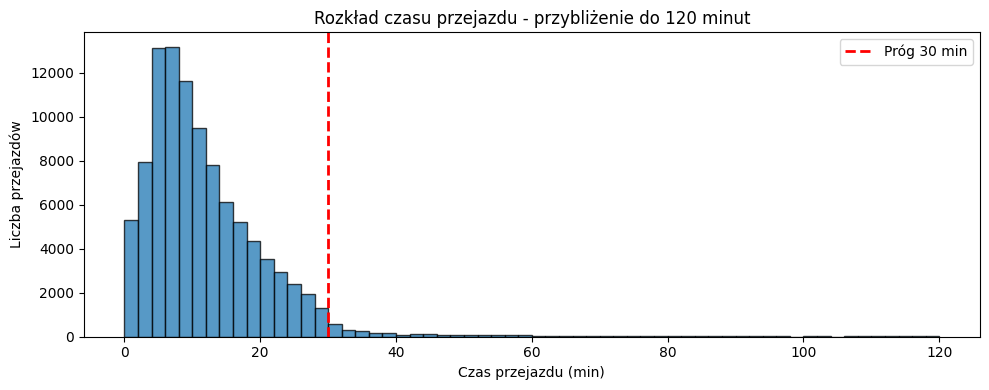

Zapisano: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/plots/duration_free_tier_cliff_zoom.png


In [74]:
duration_sec = pd.to_numeric(sample_df["duration (sec.)"], errors="coerce").dropna()
duration_min = duration_sec / 60.0
duration_min_zoom = duration_min[(duration_min >= 0) & (duration_min <= 120)]

fig = plt.figure(figsize=(10, 4))
plt.hist(duration_min_zoom, bins=60, range=(0, 120), alpha=0.75, edgecolor="black")
plt.axvline(30, color="red", linestyle="--", linewidth=2, label="Próg 30 min")
plt.title("Rozkład czasu przejazdu - przybliżenie do 120 minut")
plt.xlabel("Czas przejazdu (min)")
plt.ylabel("Liczba przejazdów")
plt.legend()
plt.tight_layout()

zoom_path = plot_dir / "duration_free_tier_cliff_zoom.png"
fig.savefig(zoom_path, dpi=150)
plt.show()
print("Zapisano:", zoom_path)

### 1.4.15 Korytarze Transportowe i Dynamika Przepływów (Top O-D Corridors)
**Kontekst biznesowo-operacyjny:**
W tej sekcji identyfikujemy główne magistrale ruchu w systemie. Analiza macierzy Origin-Destination (O-D) na poziomie lokalizacji fizycznych pozwala na precyzyjne wyznaczenie "śródbudowanych" korytarzy transportowych, które generują największe obciążenie floty.

**Kluczowe wymiary analityczne widoku:**
* **Segmentacja czasowa (Time-of-Day Segment):** Pozwala odróżnić poranne szczyty komunikacyjne od popołudniowych powrotów, co jest kluczowe dla dynamicznego planowania relokacji.
* **Charakterystyka Topograficzna (Elevation Delta & Gradient):** Wprowadzenie różnicy wzniesień dla każdej pary stacji pozwala algorytmicznie uzasadnić kierunkowość ruchu. Trasy o ujemnym nachyleniu (z górki) są naturalnie preferowane przez użytkowników, co prowadzi do drenażu stacji położonych wyżej i konieczności ich stałego zasilania przez operatora.
* **Metryki Wydajności (Distance & Duration):** Zestawienie średniego dystansu i czasu pozwala wyłapać anomalie lub trasy o niskiej przepustowości (np. przez korki lub brak ścieżek rowerowych), co stanowi wsad do rekomendacji dla infrastruktury miejskiej.

Poniższe zestawienie stanowi ranking TOP 20 korytarzy o najwyższym priorytecie logistycznym.


In [75]:
display(
    origin_destination_df[[
        'origin_physical_location_id', 'destination_physical_location_id',
        'time_of_day_segment', 'route_trip_count',
        'avg_route_distance_m', 'avg_route_duration_sec',
        'elevation_delta_meters', 'route_gradient_type'
    ]].sort_values('route_trip_count', ascending=False).head(20)
)


,origin_physical_location_id,destination_physical_location_id,time_of_day_segment,route_trip_count,avg_route_distance_m,avg_route_duration_sec,elevation_delta_meters,route_gradient_type
0,LOC_60.1843_24.8267,LOC_60.1881_24.8350,afternoon_peak,15111,787.322264,286.920191,3.0,flat
1,LOC_60.1881_24.8350,LOC_60.1843_24.8267,afternoon_peak,11442,770.546673,258.187773,-3.0,flat
53106,LOC_60.1843_24.8267,LOC_60.1881_24.8350,evening,10393,797.509034,298.630349,3.0,flat
149204,LOC_60.1635_24.9145,LOC_60.1648_24.9010,morning_peak,9641,909.880929,346.958847,-12.0,downhill
2,LOC_60.1635_24.9145,LOC_60.1722_24.9393,afternoon_peak,9193,2189.200534,612.704216,-3.0,flat
149205,LOC_60.1722_24.9393,LOC_60.1635_24.9145,morning_peak,8627,2194.592434,609.773473,3.0,flat
3,LOC_60.1635_24.9145,LOC_60.1635_24.9145,afternoon_peak,7662,745.417202,501.553822,0.0,flat
4,LOC_60.1568_24.9207,LOC_60.1635_24.9145,afternoon_peak,7350,1127.773419,399.526746,8.0,uphill
149206,LOC_60.1881_24.8350,LOC_60.1843_24.8267,morning_peak,7245,726.372944,230.88021,-3.0,flat
100265,LOC_60.1881_24.8350,LOC_60.1843_24.8267,midday,7223,774.855972,281.384626,-3.0,flat


### 1.4.16  Persystencja Danych i Budowa Feature Store (Data Persistence Layer)
**Kontekst biznesowo-inżynieryjny:**
Niniejsza sekcja stanowi finalizację procesu ETL (Extract, Transform, Load). Przekształcone i wzbogacone dane zostają utrwalone w sformalizowanej strukturze katalogów, tworząc solidny **Feature Store** dla całego ekosystemu analitycznego projektu.



**Standardy zapisu i interoperacyjność:**
* **Format Parquet:** Większość artefaktów zapisujemy w formacie kolumnowym `.parquet`. Gwarantuje to wysoką kompresję oraz drastyczne przyspieszenie operacji I/O dla przyszłych modeli predykcyjnych (Cele 3-5).
* **Format CSV:** Kluczowe raporty biznesowe (np. `origin_destination_top_routes.csv`, `customer_persona_summary.csv`) są dodatkowo eksportowane do formatu płaskiego, co umożliwia ich bezpośrednią konsumpcję przez narzędzia BI (Tableau, PowerBI) bez konieczności angażowania środowiska Python.
* **Modularność (Atomic Saves):** Rozbicie zapisu na atomowe komponenty (od topografii, przez grafy, aż po profile temporalne) pozwala na selektywne odświeżanie danych w przyszłości, co krytycznie obniża koszty obliczeniowe (Cloud Costs) i czas trwania potoków CI/CD.

Wszystkie wygenerowane obiekty stanowią kompletny i ustandaryzowany wsad do dalszych etapów prac nad Inteligentnym Systemem Relokacji.

In [76]:
save_parquet(variable_catalog_df, 'variable_catalog.parquet')
save_csv(variable_catalog_df, 'variable_catalog.csv')

save_parquet(hourly_weather_df, 'hourly_weather_reference.parquet')
save_parquet(daily_weather_df, 'daily_weather_reference.parquet')
save_csv(weather_timezone_audit_df, 'weather_timezone_audit.csv')
save_parquet(annual_forecast_daily_df, 'annual_forecast_daily_data.parquet')
save_parquet(monthly_forecast_df, 'monthly_forecast_ready_data.parquet')
save_csv(monthly_forecast_df, 'monthly_forecast_ready_data.csv')
save_parquet(next_day_forecast_daily_df, 'daily_forecast_ready_data.parquet')


2026-03-01 21:57:05,398 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/variable_catalog.parquet
2026-03-01 21:57:05,427 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/variable_catalog.csv
2026-03-01 21:57:05,567 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_weather_reference.parquet
2026-03-01 21:57:05,605 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_weather_reference.parquet
2026-03-01 21:57:05,644 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/weather_timezone_audit.csv
2026-03-01 21:57:05,839 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/annual_forecast_daily_data.parquet
2026-03-01 21:57:05,901 | INFO | Zapisano plik: /mnt/c/Users/User

PosixPath('/mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_forecast_ready_data.parquet')

In [77]:
save_parquet(daily_df, 'daily_aggregated_data.parquet')
save_parquet(station_departure_df, 'daily_station_departure_aggregated_data.parquet')
save_parquet(station_return_df, 'daily_station_return_aggregated_data.parquet')


2026-03-01 21:57:13,228 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_aggregated_data.parquet
2026-03-01 21:57:16,698 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_station_departure_aggregated_data.parquet
2026-03-01 21:57:17,906 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_station_return_aggregated_data.parquet


PosixPath('/mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/daily_station_return_aggregated_data.parquet')

In [78]:
save_parquet(station_departure_hour_df, 'hourly_station_departure_aggregated_data.parquet')
save_parquet(station_return_hour_df, 'hourly_station_return_aggregated_data.parquet')
save_parquet(station_alert_hour_df, 'hourly_station_alert_view.parquet')
save_parquet(microzone_reference_df, 'microzone_reference.parquet')
save_parquet(microzone_alert_hour_df, 'hourly_microzone_alert_view.parquet')
save_parquet(station_alert_prediction_df, 'hourly_station_alert_prediction_view.parquet')
save_parquet(station_capacity_df, 'station_capacity_reference.parquet')


2026-03-01 21:57:34,353 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_station_departure_aggregated_data.parquet
2026-03-01 21:57:44,583 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_station_return_aggregated_data.parquet
2026-03-01 21:57:44,670 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_station_alert_view.parquet
2026-03-01 21:57:44,693 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/microzone_reference.parquet
2026-03-01 21:57:44,738 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_microzone_alert_view.parquet
2026-03-01 21:57:44,871 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/hourly_station_alert_prediction_view.parquet


PosixPath('/mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_capacity_reference.parquet')

In [79]:
save_parquet(station_name_lookup_df, 'station_name_lookup.parquet')
save_parquet(stations_df, 'stations_master.parquet')
save_parquet(station_location_master_df, 'station_location_master.parquet')
save_parquet(station_elevation_df, 'station_elevation_reference.parquet')
save_parquet(customer_persona_summary_df, 'customer_persona_summary.parquet')
save_csv(customer_persona_summary_df, 'customer_persona_summary.csv')
save_parquet(station_persona_profile_df, 'station_persona_profile.parquet')
save_parquet(station_graph_features_df, 'station_graph_features.parquet')
save_parquet(station_lifecycle_df, 'station_lifecycle_analysis.parquet')
save_parquet(station_rentals_df, 'station_rentals_analysis.parquet')
save_parquet(station_temporal_profile_df, 'station_temporal_activity_profile.parquet')
save_parquet(origin_destination_df, 'origin_destination_matrix.parquet')
save_csv(origin_destination_df.sort_values('route_trip_count', ascending=False).head(CONFIG.od_top_routes_limit), 'origin_destination_top_routes.csv')
save_parquet(station_business_df, 'station_business_analysis.parquet')


2026-03-01 21:57:55,638 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_name_lookup.parquet
2026-03-01 21:57:55,681 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/stations_master.parquet
2026-03-01 21:57:55,732 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_location_master.parquet
2026-03-01 21:57:55,754 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_elevation_reference.parquet
2026-03-01 21:57:55,782 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/customer_persona_summary.parquet
2026-03-01 21:57:55,795 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/customer_persona_summary.csv
2026-03-01 21:57:55,826 | INFO | Zapisano plik: /mnt/c/U

PosixPath('/mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/station_business_analysis.parquet')

In [80]:
for name, df in business_views.items():
    save_parquet(df, f'{name}.parquet')
    save_csv(df, f'{name}.csv')

print('Wszystkie główne pliki zostały zapisane do:', OUTPUT_DIR)

2026-03-01 21:58:06,992 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/day_of_week_kpi.parquet
2026-03-01 21:58:07,004 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/day_of_week_kpi.csv
2026-03-01 21:58:07,041 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/month_kpi.parquet
2026-03-01 21:58:07,056 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/month_kpi.csv
2026-03-01 21:58:07,177 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/holiday_kpi.parquet
2026-03-01 21:58:07,203 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data/holiday_kpi.csv
2026-03-01 21:58:07,244 | INFO | Zapisano plik: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data

Wszystkie główne pliki zostały zapisane do: /mnt/c/Users/User/Desktop/6_samodzielny_projekt_koncowy/1_Wstępna analiza/data


## Podsumowanie działu 1.4 Analiza danych

**Kontekst inżynieryjny:** W dziale `1.4` przeprowadzono wielowarstwową analizę danych systemu rowerowego oraz zbudowano biznesowo-operacyjne profile infrastruktury. Proces rozpoczęto od przygotowania KPI systemowych i analizy cyklu życia stacji, a następnie przygotowano profile aktywności lokalizacji, heurystyki person użytkowników oraz analizę centralności grafowej infrastruktury. W kolejnych etapach wykonano identyfikację stacji typu `sink`, estymację przepustowości infrastrukturalnej, analizę sezonowości szeregów czasowych, macierze korelacji biznesowych oraz zestaw wizualnych diagnostyk EDA. Finalnie przeprowadzono analizę przepływów Origin–Destination, identyfikację głównych korytarzy transportowych oraz zapis kompletu warstw analitycznych do repozytorium Feature Store projektu.

**Interpretacja wyniku:** Analiza danych została wykonana dla `344` fizycznych lokalizacji systemowych. Warstwa `station_business_df` osiągnęła rozmiar `(344, 52)` i skonsolidowała informacje lokalizacyjne, operacyjne, topograficzne i behawioralne w jeden biznesowy profil stacji. Analiza centralności sieci wygenerowała wskaźniki `pagerank_centrality` oraz `betweenness_score`, umożliwiające identyfikację kluczowych hubów infrastruktury. Mechanizm detekcji stacji `sink` pozwolił wyznaczyć lokalizacje o trwałej asymetrii przepływów, natomiast estymacja przepustowości wygenerowała warstwę `estimated_capacity_df` opisującą limity infrastrukturalne stacji. Analiza sezonowości potwierdziła silną zmienność aktywności systemu w zależności od miesiąca, dnia tygodnia oraz warunków pogodowych. Finalnie zapisano komplet artefaktów analitycznych, obejmujących m.in. `station_business_analysis.parquet`, `station_graph_features.parquet`, `origin_destination_matrix.parquet`, `station_persona_profile.parquet`, `estimated_capacity_reference.parquet` oraz zestaw diagnostycznych wizualizacji EDA.

**Znaczenie biznesowe:** Dział `1.4` przekształca dane operacyjne w uporządkowaną warstwę wiedzy biznesowej o funkcjonowaniu całej sieci rowerowej. Dzięki analizie centralności, przepływów i sezonowości możliwe staje się identyfikowanie krytycznych hubów logistycznych, lokalizacji przeciążonych oraz stacji wymagających zwiększonej relokacji rowerów. Profile person użytkowników i analiza korytarzy transportowych pozwalają lepiej rozumieć strukturę mobilności miejskiej, natomiast estymacja przepustowości infrastruktury wspiera planowanie operacyjne i optymalizację kosztów logistycznych. Utworzona warstwa analityczna stanowi bezpośredni fundament dla dalszego Feature Engineering, modelowania Machine Learning oraz systemów wspierających decyzje operacyjne.

**Wniosek:** Dział `1.4` został domknięty poprawnie i doprowadził do budowy kompletnej warstwy analitycznej oraz biznesowej dla systemu rowerowego. Zweryfikowano profile stacji, przepływy infrastrukturalne, zależności sezonowe oraz integralność analiz geoprzestrzennych i operacyjnych. Oznacza to, że środowisko analityczne oraz biznesowy profil sieci rowerowej zostały przygotowane w sposób spójny i mogą stanowić stabilną podstawę dla kolejnych etapów projektu związanych z modelowaniem predykcyjnym i aplikacjami operacyjnymi.